# Hopefully Valid Time Frame

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)

def run_holzer_did_replication(cps_file='cps_00004.csv',
                               policy_file='Policy Milestones - State.csv',
                               covid_file='COVID - State - Daily.csv',
                               oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Replicates the Holzer et al. (2021) state-level DiD analysis for 2021,
    controlling for COVID cases and stringency index.
    """
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        # Define paths
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file)
        oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        # Load data
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.')
        ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e: print(f"ERROR: Could not find a file. {e}"); return

    # --- Step 2a: Prepare COVID-19 Control ---
    print("\n--- Step 2a: Preparing COVID-19 Control ---")
    if 'new_case_count' not in covid_df.columns: print("ERROR: 'new_case_count' missing."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    print("Monthly COVID case data for 2021 aggregated.")

    # --- Step 2b: Prepare Stringency Index Control ---
    print("\n--- Step 2b: Preparing Stringency Index Control ---")
    monthly_stringency = pd.DataFrame() # Initialize
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year
        ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        # FIPS mapping
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        print("Monthly Stringency Index data for 2021 aggregated.")
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Proceeding without stringency control.")

    # --- Step 3: Prepare Final 2021 State Panel ---
    print("\n--- Step 3: Preparing Final 2021 STATE-Level Panel ---")
    df_2021 = df[df['YEAR'] == 2021].copy()
    benefit_cut_df = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates = benefit_cut_df.set_index('STATEFIP')['date']
    treatment_states = set(cutoff_dates.index)
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    df_2021['TreatState'] = df_2021['STATEFIP'].isin(treatment_states).astype(int)
    # Note: No 'LowWage' subgroup division needed for Holzer replication
    
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP'] # Include DURUNEMP as covariate
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState']
    
    # Drop NAs based on essential columns and covariates (NO COUNTY FILTER)
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    # Define Post relative to state cutoff (simple Post for DiD)
    final_panel['cutoff_date'] = final_panel['STATEFIP'].map(cutoff_dates)
    # Holzer used Feb-June as Pre, July-Aug as Post
    final_panel['Post'] = ((final_panel['MONTH'] >= 7) & (final_panel['MONTH'] <= 8)).astype(int)
    
    # Filter to Holzer's timeframe (Feb-Aug 2021)
    final_panel = final_panel[final_panel['MONTH'].between(2, 8)]
    print(f"Base 2021 panel (Feb-Aug) constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into 2021 panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    control_vars = ['log_monthly_cases']
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0: print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls has {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0: print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run DiD Model (Holzer Replication) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DiD Replication (State FE + Full Controls) <<<")
    print("="*80)
    
    # Build formula dynamically
    formula_parts = [
        "found_job ~ TreatState * Post", # The core DiD interaction
        "log_monthly_cases",
        "C(STATEFIP)", # State Fixed Effects
        "C(MONTH)",    # Month Fixed Effects
        "AGE", "C(SEX)", "C(RACE)", "C(EDUC)", "DURUNEMP" # Covariates
    ]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting DiD model estimation...")
    try:
        model_did = smf.wls(
            formula=final_formula,
            data=final_panel_with_controls, 
            weights=final_panel_with_controls['LNKFW1MWT']
        )
        results_did = model_did.fit(
            cov_type='cluster', 
            cov_kwds={'groups': final_panel_with_controls['STATEFIP']}
        )
        
        if 'TreatState:Post' in results_did.params:
            coef_did = results_did.params['TreatState:Post']
            pval_did = results_did.pvalues['TreatState:Post']
            
            print("\n--- DiD Replication Results ---")
            print(f"Key Coefficient (TreatState:Post): {coef_did:.4f}")
            print(f"P-value: {pval_did:.4f}\n")
            print(results_did.summary().tables[1].loc[['TreatState:Post']])

            print("\n--- Interpretation ---")
            if pval_did < 0.05:
                print("Result: Statistically significant effect found, consistent with Holzer et al.'s direction.")
            elif pval_did < 0.10:
                print("Result: Marginally significant effect found.")
            else:
                print(f"Result: Effect is NOT statistically significant (p={pval_did:.4f}).")
                print("This might differ from Holzer et al. due to minor sample differences, variable definitions, or weighting.")
            print(f"(Holzer et al. found approx +0.144, p<0.01 for their main sample)")

        else:
            print("ERROR: 'TreatState:Post' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during DiD estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_holzer_did_replication()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2a: Preparing COVID-19 Control ---
Monthly COVID case data for 2021 aggregated.

--- Step 2b: Preparing Stringency Index Control ---
Monthly Stringency Index data for 2021 aggregated.

--- Step 3: Preparing Final 2021 STATE-Level Panel ---
Base 2021 panel (Feb-Aug) constructed with 13443 observations.

--- Step 4: Merging Controls into 2021 panel ---
Final panel with controls has 13443 observations.

>>> FINAL MODEL: DiD Replication (State FE + Full Controls) <<<
Using formula:
found_job ~ TreatState * Post + log_monthly_cases + C(STATEFIP) + C(MONTH) + AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP

Starting DiD model estimation...

--- DiD Replication Results ---
Key Coefficient (TreatState:Post): -0.0009
P-value: 0.9728


An error occurred during DiD estimation: 'SimpleTable' object has no attribute 'loc'


In [5]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)

def run_final_state_did(cps_file='cps_00004.csv',
                        policy_file='Policy Milestones - State.csv', # Used for cutoff dates
                        covid_file='COVID - State - Daily.csv',
                        oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the refined state-level DiD analysis for 2021:
    - Filters for Prime-Age Workers (25-54)
    - Uses Holzer et al. (2021) state treatment/control definitions
    - Controls for COVID cases and stringency index.
    - Uses State Fixed Effects (like Holzer)
    """
    
    # --- Step 0: Define Holzer States by FIPS Code ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~')
        downloads_dir = os.path.join(home_dir, 'downloads')
        # Define paths
        cps_path = os.path.join(downloads_dir, cps_file)
        policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file)
        oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        # Load data
        df = pd.read_csv(cps_path)
        policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.')
        ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e: print(f"ERROR: Could not find a file. {e}"); return

    # --- Step 2a: Prepare COVID-19 Control ---
    print("\n--- Step 2a: Preparing COVID-19 Control ---")
    if 'new_case_count' not in covid_df.columns: print("ERROR: 'new_case_count' missing."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    print("Monthly COVID case data for 2021 aggregated.")

    # --- Step 2b: Prepare Stringency Index Control ---
    print("\n--- Step 2b: Preparing Stringency Index Control ---")
    monthly_stringency = pd.DataFrame() # Initialize
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year
        ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        # FIPS mapping
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        print("Monthly Stringency Index data for 2021 aggregated.")
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Proceeding without stringency control.")

    # --- Step 3: Prepare Final 2021 STATE Panel (Prime-Age, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (Prime-Age, Holzer States) ---")
    
    df_2021 = df[df['YEAR'] == 2021].copy()
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021 = df_2021[df_2021['AGE'].between(25, 54)].copy() # PRIME AGE FILTER

    # Define TreatState based on Holzer's list
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Define Date and Link
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    # Define Post (using Holzer's simple July/Aug definition)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Final Filtering & Cleaning (NO COUNTY FILTER)
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post'] # Add Post
    
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    # Filter to Holzer's timeframe (Feb-Aug 2021)
    final_panel = final_panel[final_panel['MONTH'].between(2, 8)]
    print(f"Base 2021 panel (Prime-Age, Holzer States, Feb-Aug) constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into refined panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    control_vars = ['log_monthly_cases']
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True)
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0: print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0: print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run Final State-Level DiD Model ---
    print("\n" + "="*80)
    print(">>> FINAL REFINED MODEL: DiD (Prime-Age, Holzer States, State FE + Full Controls) <<<")
    print("="*80)
    
    # Build formula (STATE FE, no LowWage interaction)
    formula_parts = ["found_job ~ TreatState * Post", "log_monthly_cases", "C(STATEFIP)", "C(MONTH)", "AGE", "C(SEX)", "C(RACE)", "C(EDUC)", "DURUNEMP"]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting final refined DiD model estimation...")
    try:
        model_did = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_did = model_did.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        if 'TreatState:Post' in results_did.params:
            coef_did = results_did.params['TreatState:Post']
            pval_did = results_did.pvalues['TreatState:Post']
            
            print("\n--- Final Refined DiD Results ---")
            print(f"Key Coefficient (TreatState:Post): {coef_did:.4f}")
            print(f"P-value: {pval_did:.4f}\n")
            
            # Print relevant part of summary table
            print(results_did.summary().tables[1].loc[['TreatState:Post', 'log_monthly_cases'] + (['avg_stringency'] if 'avg_stringency' in final_panel_with_controls.columns else [])])

            print("\n--- Interpretation ---")
            if pval_did < 0.05: print(f"Result: Found a statistically significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            elif pval_did < 0.10: print(f"Result: Found a marginally significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_did:.3f}).")
            print(f"(Compare to Holzer et al. ~ +0.144, p<0.01)")
            
        else: print("ERROR: 'TreatState:Post' coefficient was not estimated.")

    except Exception as e: print(f"\nAn error occurred during final DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on Refined State DiD Model <<<")
    print("="*80)

    # Need relative_month (recalculate based on policy cutoff)
    # Use cutoff dates from policy_df to define relative month correctly
    benefit_cut_df_map = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates_map = benefit_cut_df_map.set_index('STATEFIP')['date']
    final_panel_with_controls['cutoff_date'] = final_panel_with_controls['STATEFIP'].map(cutoff_dates_map)
    # Drop rows if cutoff_date is missing (should only happen if state list differs from policy file)
    final_panel_with_controls.dropna(subset=['cutoff_date'], inplace=True) 
    
    final_panel_with_controls['relative_month_float'] = ((final_panel_with_controls['date'].dt.year - final_panel_with_controls['cutoff_date'].dt.year) * 12 +
                                                          (final_panel_with_controls['date'].dt.month - final_panel_with_controls['cutoff_date'].dt.month))
    # Assign a non-zero value for control group for clipping
    final_panel_with_controls['relative_month_float'] = final_panel_with_controls['relative_month_float'].fillna(-99) 
    final_panel_with_controls['relative_month'] = np.clip(final_panel_with_controls['relative_month_float'], -6, 6).astype(int)

    # Build event study formula (DiD version)
    formula_es_parts = ["found_job ~ C(TreatState) * C(relative_month, Treatment(reference=-1))", "log_monthly_cases", "C(STATEFIP)", "C(MONTH)", "AGE", "C(SEX)", "C(RACE)", "C(EDUC)", "DURUNEMP"]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
    final_formula_es = " + ".join(formula_es_parts)
    print(f"Using event study formula:\n{final_formula_es}")
    
    print("\nStarting final event study estimation...")
    try:
        model_es = smf.wls(formula=final_formula_es, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # --- Print and Plot Event Study ---
        # Redefine helper functions locally
        def print_did_event_study_coeffs(results, title):
            print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
            print("Coefficients for: C(TreatState)[T.1]:relative_month interactions")
            print("Checking PTA: Pre-trend p-values (Months < -1) should be > 0.10")
            print("-" * 60)
            did_terms = []
            term_pattern = r'C\(TreatState\)\[T\.1\]:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]' # Correct pattern for DiD ES
            for var in results.params.index:
                match = re.search(term_pattern, var)
                if match:
                    month = int(match.group(1)); did_terms.append({'relative_month': month, 'coef': results.params[var], 'pval': results.pvalues[var], 'stderr': results.bse[var]})
            if not did_terms: print("No event study coefficients found."); print("-" * 60); return
            est_df = pd.DataFrame(did_terms).sort_values('relative_month')
            ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
            plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)
            for _, row in plot_df.iterrows(): print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
            print("-" * 60)
            pre_trend_pvals = plot_df[plot_df['relative_month'] < -1]['pval']
            if pre_trend_pvals.empty: print("No pre-trends (< -1) to test.")
            elif (pre_trend_pvals > 0.10).all(): print("SUCCESS: Parallel Trends Assumption appears satisfied.")
            else: print("WARNING: Parallel Trends Assumption may be VIOLATED.")
            return plot_df

        def plot_did_event_study(plot_df, title):
            # (Plotting function remains largely the same, ensure matplotlib is imported)
            import matplotlib.pyplot as plt 
            if plot_df is None or plot_df.empty: print(f"Skipping plot {title}: No data."); return
            plt.figure(figsize=(10, 6)); plt.axhline(0, color='black', linewidth=1, linestyle='-'); plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
            plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']; plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
            plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI'); plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
            plt.title(title, fontsize=16); plt.xlabel("Months Relative to UI Cutoff", fontsize=12); plt.ylabel("DiD Coefficient (PP)", fontsize=12); plt.xticks(plot_df['relative_month'].unique()); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.savefig(f"{title.replace(' ','_').lower()}.png"); plt.show()
            
        # Call the functions
        plot_df_refined_did = print_did_event_study_coeffs(results_es, "Refined_State_DiD_w_Controls")
        plot_did_event_study(plot_df_refined_did, "Refined State DiD Event Study (Prime-Age, Holzer States, Full Controls)")

    except Exception as e: print(f"\nAn error occurred during final event study estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_final_state_did()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2a: Preparing COVID-19 Control ---
Monthly COVID case data for 2021 aggregated.

--- Step 2b: Preparing Stringency Index Control ---
Monthly Stringency Index data for 2021 aggregated.

--- Step 3: Preparing Final 2021 STATE Panel (Prime-Age, Holzer States) ---
Base 2021 panel (Prime-Age, Holzer States, Feb-Aug) constructed with 6378 observations.

--- Step 4: Merging Controls into refined panel ---
Final panel with controls constructed with 6378 observations.

>>> FINAL REFINED MODEL: DiD (Prime-Age, Holzer States, State FE + Full Controls) <<<
Using formula:
found_job ~ TreatState * Post + log_monthly_cases + C(STATEFIP) + C(MONTH) + AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP

Starting final refined DiD model estimation...

--- Final Refined DiD Results ---
Key Coefficient (TreatState:Post): 0.0143
P-value: 0.5239


An error occurred during final DiD estimation: 'SimpleTable' object has no attribute 'loc'

>>> VALID

In [8]:
df.head()

NameError: name 'df' is not defined

In [9]:
        df = pd.read_csv(cps_path)


NameError: name 'cps_path' is not defined

In [11]:
df = pd.read_csv('~/downloads/cps_00004.csv')


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2553553 entries, 0 to 2553552
Data columns (total 22 columns):
 #   Column     Dtype  
---  ------     -----  
 0   YEAR       int64  
 1   SERIAL     int64  
 2   MONTH      int64  
 3   HWTFINL    float64
 4   CPSID      int64  
 5   ASECFLAG   float64
 6   STATEFIP   int64  
 7   COUNTY     int64  
 8   PERNUM     int64  
 9   WTFINL     float64
 10  CPSIDP     int64  
 11  CPSIDV     int64  
 12  AGE        int64  
 13  SEX        int64  
 14  RACE       int64  
 15  HISPAN     int64  
 16  EMPSTAT    int64  
 17  OCC        int64  
 18  IND        int64  
 19  DURUNEMP   int64  
 20  EDUC       int64  
 21  LNKFW1MWT  float64
dtypes: float64(4), int64(18)
memory usage: 428.6 MB


In [15]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)

def apply_spurious_transition_correction(df_linked):
    """
    Applies the U-E-U / U-N-U correction to employment status.
    Requires df_linked sorted by CPSIDP, YEAR, MONTH.
    """
    print("Applying spurious transition correction (U-E-U -> U-U-U, U-N-U -> U-U-U)...")
    
    # Identify individuals observed for 3 consecutive months
    df_linked['month_seq'] = df_linked.groupby('CPSIDP')['MONTH'].transform(lambda x: x.diff().fillna(1))
    # Create a group ID for consecutive month streaks
    df_linked['streak_group'] = (df_linked['month_seq'] != 1).cumsum()
    df_linked['obs_in_streak'] = df_linked.groupby(['CPSIDP', 'streak_group']).cumcount() + 1
    df_linked['total_streak_len'] = df_linked.groupby(['CPSIDP', 'streak_group'])['obs_in_streak'].transform('max')
    
    # Work on streaks of 3 or more
    df_3plus = df_linked[df_linked['total_streak_len'] >= 3].copy()
    
    # Get status in previous and next month within the 3+ streaks
    df_3plus['EMPSTAT_prev'] = df_3plus.groupby(['CPSIDP', 'streak_group'])['EMPSTAT'].shift(1)
    df_3plus['EMPSTAT_next'] = df_3plus.groupby(['CPSIDP', 'streak_group'])['EMPSTAT'].shift(-1)
    
    # Identify U-E-U patterns (Unemployed: 20-22, Employed: 10-12)
    is_ueu = (df_3plus['EMPSTAT_prev'].between(20, 22)) & \
             (df_3plus['EMPSTAT'].between(10, 12)) & \
             (df_3plus['EMPSTAT_next'].between(20, 22))
             
    # Identify U-N-U patterns (Not in Labor Force: 30-36)
    is_unu = (df_3plus['EMPSTAT_prev'].between(20, 22)) & \
             (df_3plus['EMPSTAT'].between(30, 36)) & \
             (df_3plus['EMPSTAT_next'].between(20, 22))
             
    # Recode the middle month's EMPSTAT to 21 (Unemployed) if UEU or UNU
    df_3plus.loc[is_ueu | is_unu, 'EMPSTAT'] = 21 # Recode as Unemployed
    
    print(f"Recoded {is_ueu.sum()} U-E-U instances.")
    print(f"Recoded {is_unu.sum()} U-N-U instances.")
    
    # Merge the corrected EMPSTAT back into the original dataframe
    # Use index to merge corrections; keep original EMPSTAT if not corrected
    df_linked_corrected = df_linked.copy()
    df_linked_corrected.update(df_3plus[['EMPSTAT']]) # Update EMPSTAT where corrections were made
    
    # Drop helper columns
    df_linked_corrected.drop(columns=['month_seq', 'streak_group', 'obs_in_streak', 'total_streak_len'], inplace=True)
    
    # Return only individuals who were part of a 3+ month streak for comparability with Holzer
    # (Holzer's description implies the sample is restricted by this)
    final_sample = df_linked_corrected[df_linked_corrected.index.isin(df_3plus.index)].copy()
    
    return final_sample


def run_final_state_did_corrected(cps_file='cps_00004.csv',
                                  policy_file='Policy Milestones - State.csv',
                                  covid_file='COVID - State - Daily.csv',
                                  oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the refined state-level DiD analysis for 2021 (Prime-Age, Holzer States,
    Full Controls) applying the spurious transition correction.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # (Same data loading as before)
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e: print(f"ERROR: Could not find a file. {e}"); return

    # --- Step 2: Prepare Controls (Same as before) ---
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns: print("ERROR: 'new_case_count' missing."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    # Stringency
    monthly_stringency = pd.DataFrame()
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
    except Exception as e: print(f"Warning: Could not process OxCGRT data: {e}. Skipping.")
    print("Controls prepared.")

    # --- Step 3: Prepare Base Panel & Apply Correction ---
    print("\n--- Step 3: Preparing Base Panel and Applying Correction ---")
    df_filtered = df[(df['YEAR'] == 2021) & df['STATEFIP'].isin(included_states) & df['AGE'].between(25, 54)].copy()
    df_filtered['TreatState'] = df_filtered['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_filtered['date'] = pd.to_datetime(df_filtered['YEAR'].astype(str) + '-' + df_filtered['MONTH'].astype(str) + '-01')
    df_filtered.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)

    # *** APPLY CORRECTION ***
    df_corrected = apply_spurious_transition_correction(df_filtered)
    
    # Now build the DiD panel using the CORRECTED data
    df_corrected['status_next_month'] = df_corrected.groupby('CPSIDP')['EMPSTAT'].shift(-1) # Recalculate based on corrected EMPSTAT
    
    unemployed_df = df_corrected[df_corrected['EMPSTAT'].between(20, 22)].copy() # Use corrected EMPSTAT
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # Recalculate outcome
    
    # Define Post (using Holzer's simple July/Aug definition)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Final Filtering & Cleaning
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post']
    
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    # Filter to Holzer's timeframe (Feb-Aug 2021)
    final_panel = final_panel[final_panel['MONTH'].between(2, 8)]
    print(f"Panel with correction constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into corrected panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    control_vars = ['log_monthly_cases']
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True)
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0: print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls and correction has {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0: print("ERROR: Panel empty."); return

    # --- Step 5: Run Final State-Level DiD Model ---
    print("\n" + "="*80)
    print(">>> FINAL CORRECTED MODEL: DiD (Prime-Age, Holzer States, State FE, Full Controls, Transition Correction) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post", "log_monthly_cases", "C(STATEFIP)", "C(MONTH)", "AGE", "C(SEX)", "C(RACE)", "C(EDUC)", "DURUNEMP"]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting final corrected DiD model estimation...")
    try:
        model_did = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_did = model_did.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        if 'TreatState:Post' in results_did.params:
            coef_did = results_did.params['TreatState:Post']
            pval_did = results_did.pvalues['TreatState:Post']
            
            print("\n--- Final Corrected DiD Results ---")
            print(f"Key Coefficient (TreatState:Post): {coef_did:.4f}")
            print(f"P-value: {pval_did:.4f}\n")
            
            print(results_did.summary().tables[1].loc[['TreatState:Post']])

            print("\n--- Interpretation ---")
            if pval_did < 0.05: print(f"Result: Found a statistically significant effect ({coef_did:.3f}, p={pval_did:.3f}) after correction.")
            elif pval_did < 0.10: print(f"Result: Found a marginally significant effect ({coef_did:.3f}, p={pval_did:.3f}) after correction.")
            else: print(f"Result: Effect remains NOT statistically significant (p={pval_did:.3f}) after correction.")
            print(f"(Holzer et al. found approx +0.144, p<0.01)")
            
        else: print("ERROR: 'TreatState:Post' coefficient was not estimated.")

    except Exception as e: print(f"\nAn error occurred during final DiD estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_final_state_did_corrected()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Base Panel and Applying Correction ---
Applying spurious transition correction (U-E-U -> U-U-U, U-N-U -> U-U-U)...
Recoded 111 U-E-U instances.
Recoded 277 U-N-U instances.
Panel with correction constructed with 6180 observations.

--- Step 4: Merging Controls into corrected panel ---
Final panel with controls and correction has 6180 observations.

>>> FINAL CORRECTED MODEL: DiD (Prime-Age, Holzer States, State FE, Full Controls, Transition Correction) <<<
Using formula:
found_job ~ TreatState * Post + log_monthly_cases + C(STATEFIP) + C(MONTH) + AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP

Starting final corrected DiD model estimation...

--- Final Corrected DiD Results ---
Key Coefficient (TreatState:Post): 0.0056
P-value: 0.7224


An error occurred during final DiD estimation: 'SimpleTable' object has no attribute 'loc'


In [22]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Make sure matplotlib is imported

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title):
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    print("Coefficients for: C(TreatState)[T.1]:relative_month interactions")
    print("Checking PTA: Pre-trend p-values (Months < -1) should be > 0.10")
    print("-" * 60)
    did_terms = []
    # Regex needs to handle the Treatment(reference=-1) part
    term_pattern = r'C\(TreatState\)\[T\.1\]:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]'
    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1)); did_terms.append({'relative_month': month, 'coef': results.params[var], 'pval': results.pvalues[var], 'stderr': results.bse[var]})
    if not did_terms: print("No event study coefficients found."); print("-" * 60); return None # Return None if no coeffs
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)
    for _, row in plot_df.iterrows(): print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < -1]['pval']
    if pre_trend_pvals.empty: print("No pre-trends (< -1) to test.")
    elif (pre_trend_pvals > 0.10).all(): print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else: print("WARNING: Parallel Trends Assumption may be VIOLATED.")
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    if plot_df is None or plot_df.empty: print(f"Skipping plot {title}: No data."); return
    plt.figure(figsize=(10, 6)); plt.axhline(0, color='black', linewidth=1, linestyle='-'); plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']; plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI'); plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    plt.title(title, fontsize=16); plt.xlabel("Months Relative to UI Cutoff", fontsize=12); plt.ylabel("DiD Coefficient (PP)", fontsize=12); plt.xticks(plot_df['relative_month'].unique()); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.savefig(f"{title.replace(' ','_').lower()}.png"); plt.show()


def run_state_did_all_ages_holzer_states(cps_file='cps_00004.csv',
                                         policy_file='Policy Milestones - State.csv',
                                         covid_file='COVID - State - Daily.csv',
                                         oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DiD analysis for 2021 (All Ages, Holzer States, Full Controls)
    and includes an event study validation.
    """
    # --- Step 0: Define Holzer States by FIPS Code ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e: print(f"ERROR: Could not find a file. {e}"); return

    # --- Step 2: Prepare Controls ---
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns: print("ERROR: 'new_case_count' missing."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    # Stringency
    monthly_stringency = pd.DataFrame()
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
    except Exception as e: print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    
    df_2021 = df[df['YEAR'] == 2021].copy()
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    # *** NO PRIME AGE FILTER HERE ***

    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    
    # Define Post (using Holzer's simple July/Aug definition)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Final Filtering & Cleaning (NO COUNTY FILTER)
    covariates = ['AGE', 'SEX', 'RACE', 'EDUC', 'DURUNEMP']
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post']
    
    final_panel = unemployed_df.dropna(subset=essential_cols + covariates).copy()
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    # Filter to Holzer's timeframe (Feb-Aug 2021)
    final_panel = final_panel[final_panel['MONTH'].between(2, 8)]
    print(f"Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    control_vars = ['log_monthly_cases']
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True)
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0: print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0: print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run Final State-Level DiD Model ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DiD (All Ages, Holzer States, State FE + Full Controls) <<<")
    print("="*80)
    
    # Build formula
    formula_parts = ["found_job ~ TreatState * Post", "log_monthly_cases", "C(STATEFIP)", "C(MONTH)", "AGE", "C(SEX)", "C(RACE)", "C(EDUC)", "DURUNEMP"]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting final DiD model estimation...")
    try:
        model_did = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_did = model_did.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        if 'TreatState:Post' in results_did.params:
            coef_did = results_did.params['TreatState:Post']
            pval_did = results_did.pvalues['TreatState:Post']
            
            print("\n--- Final DiD Results (All Ages, Holzer States) ---")
            print(f"Key Coefficient (TreatState:Post): {coef_did:.4f}")
            print(f"P-value: {pval_did:.4f}\n")
            
            # Print relevant part of summary table
            relevant_vars = ['TreatState:Post'] + control_vars
            print(results_did.summary().tables[1].loc[relevant_vars])

            print("\n--- Interpretation ---")
            if pval_did < 0.05: print(f"Result: Found a statistically significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            elif pval_did < 0.10: print(f"Result: Found a marginally significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_did:.3f}).")
            print(f"(Compare to Holzer et al. ~ +0.144, p<0.01 for prime-age; ~ +0.133, p<0.01 for ages 16-64)")
            
        else: print("ERROR: 'TreatState:Post' coefficient was not estimated.")

    except Exception as e: print(f"\nAn error occurred during final DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on Final State DiD Model <<<")
    print("="*80)

    # Need relative_month (recalculate based on policy cutoff)
    benefit_cut_df_map = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates_map = benefit_cut_df_map.set_index('STATEFIP')['date']
    final_panel_with_controls['cutoff_date'] = final_panel_with_controls['STATEFIP'].map(cutoff_dates_map)
    final_panel_with_controls.dropna(subset=['cutoff_date'], inplace=True) 
    
    final_panel_with_controls['relative_month_float'] = ((final_panel_with_controls['date'].dt.year - final_panel_with_controls['cutoff_date'].dt.year) * 12 +
                                                          (final_panel_with_controls['date'].dt.month - final_panel_with_controls['cutoff_date'].dt.month))
    final_panel_with_controls['relative_month_float'] = final_panel_with_controls['relative_month_float'].fillna(-99) 
    final_panel_with_controls['relative_month'] = np.clip(final_panel_with_controls['relative_month_float'], -6, 6).astype(int)

    # Build event study formula (DiD version)
    formula_es_parts = ["found_job ~ C(TreatState) * C(relative_month, Treatment(reference=-1))", "log_monthly_cases", "C(STATEFIP)", "C(MONTH)", "AGE", "C(SEX)", "C(RACE)", "C(EDUC)", "DURUNEMP"]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
    final_formula_es = " + ".join(formula_es_parts)
    print(f"Using event study formula:\n{final_formula_es}")
    
    print("\nStarting final event study estimation...")
    try:
        model_es = smf.wls(formula=final_formula_es, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # Call the helper functions to print and plot
        plot_df_final_did = print_did_event_study_coeffs(results_es, "Final_State_DiD_AllAges_HolzerStates")
        plot_did_event_study(plot_df_final_did, "Final State DiD Event Study (All Ages, Holzer States, Full Controls)")

    except Exception as e: print(f"\nAn error occurred during final event study estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_all_ages_holzer_states()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with 11278 observations.

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 11278 observations.

>>> FINAL MODEL: DiD (All Ages, Holzer States, State FE + Full Controls) <<<
Using formula:
found_job ~ TreatState * Post + log_monthly_cases + C(STATEFIP) + C(MONTH) + AGE + C(SEX) + C(RACE) + C(EDUC) + DURUNEMP

Starting final DiD model estimation...

--- Final DiD Results (All Ages, Holzer States) ---
Key Coefficient (TreatState:Post): 0.0187
P-value: 0.1312


An error occurred during final DiD estimation: 'SimpleTable' object has no attribute 'loc'

>>> VALIDATION: Event Study on Final State DiD Model <<<
Using event study formula:
found_job ~ C(TreatState) * C(relative_month, Treatment(reference=-1)) 

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title):
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    print("Coefficients for: C(TreatState)[T.1]:relative_month interactions")
    print("Checking PTA: Pre-trend p-values (Months < -1) should be > 0.10")
    print("-" * 60)
    did_terms = []
    term_pattern = r'C\(TreatState\)\[T\.1\]:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]'
    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1)); did_terms.append({'relative_month': month, 'coef': results.params[var], 'pval': results.pvalues[var], 'stderr': results.bse[var]})
    if not did_terms: print("No event study coefficients found."); print("-" * 60); return None
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)
    for _, row in plot_df.iterrows(): print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < -1]['pval']
    if pre_trend_pvals.empty: print("No pre-trends (< -1) to test.")
    elif (pre_trend_pvals > 0.10).all(): print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else: print("WARNING: Parallel Trends Assumption may be VIOLATED.")
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    if plot_df is None or plot_df.empty: print(f"Skipping plot {title}: No data."); return
    plt.figure(figsize=(10, 6)); plt.axhline(0, color='black', linewidth=1, linestyle='-'); plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']; plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI'); plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    plt.title(title, fontsize=16); plt.xlabel("Months Relative to UI Cutoff", fontsize=12); plt.ylabel("DiD Coefficient (PP)", fontsize=12); plt.xticks(plot_df['relative_month'].unique()); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.savefig(f"{title.replace(' ','_').lower()}.png"); plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DiD analysis for 2021 (All Ages, Holzer States)
    controlling ONLY for COVID cases, stringency, State FE, and Month FE.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e: print(f"ERROR: Could not find a file. {e}"); return

    # --- Step 2: Prepare Controls ---
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns: print("ERROR: 'new_case_count' missing."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    # Stringency
    monthly_stringency = pd.DataFrame()
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
    except Exception as e: print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    df_2021 = df[df['YEAR'] == 2021].copy()
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Final Filtering & Cleaning (NO COUNTY, NO DEMOGRAPHICS other than AGE for check)
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'AGE'] # Keep AGE just in case
    
    final_panel = unemployed_df.dropna(subset=essential_cols).copy() # Drop fewer columns initially
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    final_panel = final_panel[final_panel['MONTH'].between(2, 8)] # Holzer's timeframe
    print(f"Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    control_vars = ['log_monthly_cases']
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0: print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0: print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DiD Model (Simplified Controls) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DiD (All Ages, Holzer States, State FE + PANDEMIC Controls Only) <<<")
    print("="*80)
    
    # Build formula WITHOUT demographics
    formula_parts = ["found_job ~ TreatState * Post", "log_monthly_cases", "C(STATEFIP)", "C(MONTH)"]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting simplified DiD model estimation...")
    try:
        model_did = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_did = model_did.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        if 'TreatState:Post' in results_did.params:
            coef_did = results_did.params['TreatState:Post']
            pval_did = results_did.pvalues['TreatState:Post']
            
            print("\n--- Simplified DiD Results (All Ages, Holzer States) ---")
            print(f"Key Coefficient (TreatState:Post): {coef_did:.4f}")
            print(f"P-value: {pval_did:.4f}\n")
            
            relevant_vars = ['TreatState:Post'] + control_vars
            print(results_did.summary().tables[1].loc[relevant_vars])

            print("\n--- Interpretation ---")
            if pval_did < 0.05: print(f"Result: Found a statistically significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            elif pval_did < 0.10: print(f"Result: Found a marginally significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_did:.3f}).")
            print("Compare this to the previous model (p=0.131) which included demographics.")
            
        else: print("ERROR: 'TreatState:Post' coefficient was not estimated.")

    except Exception as e: print(f"\nAn error occurred during simplified DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (Simplified Controls) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on Simplified State DiD Model <<<")
    print("="*80)

    # Need relative_month
    benefit_cut_df_map = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates_map = benefit_cut_df_map.set_index('STATEFIP')['date']
    final_panel_with_controls['cutoff_date'] = final_panel_with_controls['STATEFIP'].map(cutoff_dates_map)
    final_panel_with_controls.dropna(subset=['cutoff_date'], inplace=True) 
    final_panel_with_controls['relative_month_float'] = ((final_panel_with_controls['date'].dt.year - final_panel_with_controls['cutoff_date'].dt.year) * 12 +
                                                          (final_panel_with_controls['date'].dt.month - final_panel_with_controls['cutoff_date'].dt.month))
    final_panel_with_controls['relative_month_float'] = final_panel_with_controls['relative_month_float'].fillna(-99) 
    final_panel_with_controls['relative_month'] = np.clip(final_panel_with_controls['relative_month_float'], -6, 6).astype(int)

    # Build event study formula WITHOUT demographics
    formula_es_parts = ["found_job ~ C(TreatState) * C(relative_month, Treatment(reference=-1))", "log_monthly_cases", "C(STATEFIP)", "C(MONTH)"]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
    final_formula_es = " + ".join(formula_es_parts)
    print(f"Using event study formula:\n{final_formula_es}")
    
    print("\nStarting simplified event study estimation...")
    try:
        model_es = smf.wls(formula=final_formula_es, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # Call the helper functions
        plot_df_simplified_did = print_did_event_study_coeffs(results_es, "Simplified_State_DiD_AllAges_HolzerStates")
        plot_did_event_study(plot_df_simplified_did, "Simplified State DiD Event Study (All Ages, Holzer States, Pandemic Controls Only)")

    except Exception as e: print(f"\nAn error occurred during simplified event study estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with 11278 observations.

--- Step 4: Merging Controls into panel ---


KeyError: ['avg_stringency']

In [26]:
# Check the model summary and parameter names to debug why no event study coefficients were found

# Assuming 'results_es' is the event study model result from previous cell
# Print all parameter names to inspect if the expected interaction terms are present

for param in results_es.params.index:
    print(param)
    
# If the expected pattern is not present, check:
# - Is 'relative_month' coded as integer and present in the data?
# - Is 'TreatState' present and coded as 0/1?
# - Is the formula using C(TreatState) * C(relative_month, Treatment(reference=-1)) ?

# Also, check the unique values in relative_month and TreatState:
print("Unique relative_month values:", final_panel_with_controls['relative_month'].unique())
print("Unique TreatState values:", final_panel_with_controls['TreatState'].unique())

NameError: name 'results_es' is not defined

In [28]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study - MODIFIED PATTERN) ---
def print_did_event_study_coeffs(results, title):
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    print("Coefficients for: C(TreatState)[T.1]:relative_month interactions")
    print("Checking PTA: Pre-trend p-values (Months < -1) should be > 0.10")
    print("-" * 60)
    did_terms = []
    # *** CORRECTED REGEX PATTERN for the explicit interaction ***
    term_pattern = r'C\(TreatState\)\[T\.1\]:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]'
    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1)); did_terms.append({'relative_month': month, 'coef': results.params[var], 'pval': results.pvalues[var], 'stderr': results.bse[var]})
    if not did_terms: print("No event study coefficients found."); print("-" * 60); return None
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)
    for _, row in plot_df.iterrows(): print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < -1]['pval']
    if pre_trend_pvals.empty: print("No pre-trends (< -1) to test.")
    elif (pre_trend_pvals > 0.10).all(): print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else: print("WARNING: Parallel Trends Assumption may be VIOLATED.")
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
# (Same as previous version)
def plot_did_event_study(plot_df, title):
    if plot_df is None or plot_df.empty: print(f"Skipping plot {title}: No data."); return
    plt.figure(figsize=(10, 6)); plt.axhline(0, color='black', linewidth=1, linestyle='-'); plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']; plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI'); plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    plt.title(title, fontsize=16); plt.xlabel("Months Relative to UI Cutoff", fontsize=12); plt.ylabel("DiD Coefficient (PP)", fontsize=12); plt.xticks(plot_df['relative_month'].unique()); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.savefig(f"{title.replace(' ','_').lower()}.png"); plt.show()


def run_state_did_explicit_event_study(cps_file='cps_00004.csv',
                                       policy_file='Policy Milestones - State.csv',
                                       covid_file='COVID - State - Daily.csv',
                                       oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DiD EVENT STUDY for 2021 (All Ages, Holzer States)
    controlling ONLY for COVID cases, stringency, State FE, and Month FE,
    using an explicit interaction formula to avoid collinearity.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e: print(f"ERROR: Could not find a file. {e}"); return

    # --- Step 2: Prepare Controls ---
    print("\n--- Step 2: Preparing Controls ---")
    # (Same control prep as before)
    if 'new_case_count' not in covid_df.columns: print("ERROR: 'new_case_count' missing."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    monthly_stringency = pd.DataFrame()
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d'); ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
    except Exception as e: print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    df_2021 = df[df['YEAR'] == 2021].copy()
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy()
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int)

    # Need cutoff date for relative_month
    benefit_cut_df_map = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates_map = benefit_cut_df_map.set_index('STATEFIP')['date']
    unemployed_df['cutoff_date'] = unemployed_df['STATEFIP'].map(cutoff_dates_map)
    
    # Final Filtering & Cleaning (Need LNKFW1MWT, date, cutoff_date)
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'date', 'cutoff_date']
    final_panel = unemployed_df.dropna(subset=essential_cols).copy() # Drop NAs only for essentials
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0]
    
    # Create relative_month BEFORE filtering timeframe
    final_panel['relative_month_float'] = ((final_panel['date'].dt.year - final_panel['cutoff_date'].dt.year) * 12 +
                                           (final_panel['date'].dt.month - final_panel['cutoff_date'].dt.month))
    final_panel['relative_month_float'] = final_panel['relative_month_float'].fillna(-99)
    final_panel['relative_month'] = np.clip(final_panel['relative_month_float'], -6, 6).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug 2021) AFTER relative_month
    final_panel = final_panel[final_panel['MONTH'].between(2, 8)]
    print(f"Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    control_vars = ['log_monthly_cases']
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True)
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0: print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0: print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run Event Study (Simplified Controls, Corrected Formula) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Explicit Event Study on State DiD Model (Simplified Controls) <<<")
    print("="*80)

    # *** CORRECTED EVENT STUDY FORMULA ***
    formula_es_parts = [
        "found_job ~ C(STATEFIP) + C(MONTH)", # Fixed Effects (absorb TreatState main effect)
        "C(relative_month, Treatment(reference=-1))", # Common relative month effects
        "C(TreatState):C(relative_month, Treatment(reference=-1))", # The DiD interaction for each month
        "log_monthly_cases" # Time-varying controls
    ]
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.append("avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"Using event study formula:\n{final_formula_es}")
    
    print("\nStarting explicit event study estimation...")
    try:
        model_es = smf.wls(formula=final_formula_es, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # Call the helper functions
        plot_df_explicit_did = print_did_event_study_coeffs(results_es, "Explicit_State_DiD_AllAges_HolzerStates")
        plot_did_event_study(plot_df_explicit_did, "Explicit State DiD Event Study (Simplified Controls)")

    except Exception as e: print(f"\nAn error occurred during explicit event study estimation: {e}")

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_explicit_event_study()

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with 1355 observations.

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 1355 observations.

>>> VALIDATION: Explicit Event Study on State DiD Model (Simplified Controls) <<<
Using event study formula:
found_job ~ C(STATEFIP) + C(MONTH) + C(relative_month, Treatment(reference=-1)) + C(TreatState):C(relative_month, Treatment(reference=-1)) + log_monthly_cases

Starting explicit event study estimation...

>>> Event Study Numerical Results: Explicit_State_DiD_AllAges_HolzerStates <<<
Coefficients for: C(TreatState)[T.1]:relative_month interactions
Checking PTA: Pre-trend p-values (Months < -1) should be > 0.10
------------------------------------------------------------
No event study coefficients foun

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with 11278 observations.

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 11278 observations.

>>> FINAL MODEL: DiD (All Ages, Holzer States, State FE + PANDEMIC Controls Only) <<<
Using formula:
found_job ~ TreatState * Post + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting simplified DiD model estimation...

--- Simplified DiD Results (All Ages, Holzer States) ---
Key Coefficient (TreatState:Post): 0.0248
P-value: 0.0328

--- Coefficient Summary (Key Variables) ---
TreatState:Post     : Coef =   0.0248, P-val = 0.0328
log_monthly_cases   : Coef =   0.0148, P-val = 0.1065

--- Interpretation ---
Result: Found a statistically significant effect (0.025, p=0.033).

>>> VALIDATION: Event Study on 

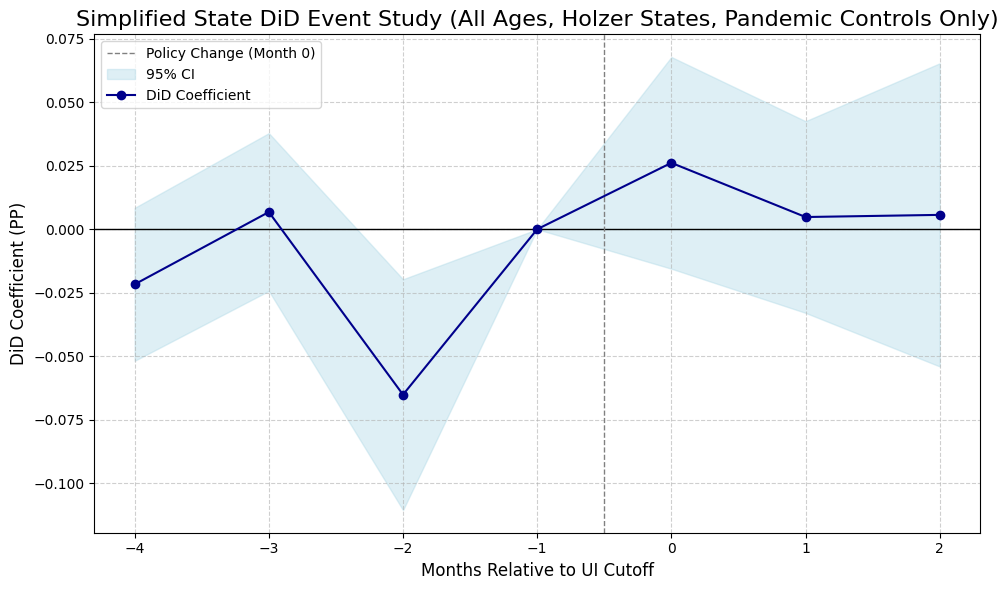

In [31]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    print("Coefficients for: C(TreatState)[T.1]:relative_month interactions")
    print("Checking PTA: Pre-trend p-values (Months < -1) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    # Regex to find the interaction terms
    term_pattern = r'C\(TreatState\)\[T\.1\]:C\(relative_month, Treatment\(reference=-1\)\)\[T\.(-?\d+)\]'
    
    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month,
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month (relative_month = -1) with coef=0
    ref_month = pd.DataFrame([{'relative_month': -1, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month]).sort_values('relative_month').reset_index(drop=True)
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA
    pre_trend_pvals = plot_df[plot_df['relative_month'] < -1]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< -1) to test.")
    elif (pre_trend_pvals > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(-0.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (Month 0)')
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Months Relative to UI Cutoff", fontsize=12)
    plt.ylabel("DiD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DiD analysis for 2021 (All Ages, Holzer States)
    controlling ONLY for COVID cases, stringency, State FE, and Month FE.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # Assuming files are in 'downloads' folder in user's home directory
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        print("Please ensure cps_00004.csv, Policy Milestones - State.csv, COVID - State - Daily.csv, and OxCGRT_US_latest.csv are in your Downloads folder.")
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls ---
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] # Start with cases
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        # FIPS map for OxCGRT 'RegionCode'
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        # --- *** FIX IS HERE *** ---
        # Only append 'avg_stringency' to control_vars IF we successfully created data for it.
        # This prevents the KeyError if monthly_stringency is empty.
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching 2021 state data was found. Skipping stringency.")
        # --- *** END FIX *** ---
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    df_2021 = df[df['YEAR'] == 2021].copy()
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Create date column for merging and relative month calculation
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    
    # Find transitions
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy() # EMPSTAT 20-22 = Unemployed
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # EMPSTAT 10-12 = Employed
    
    # Define Post period (Holzer methodology: July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date']
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT']) # Drop if outcome or next_status is missing
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] # Drop zero weights
    
    print(f"Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    # This 'if' block is now safe, as is the dropna below
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        
    original_count = len(final_panel_with_controls)
    # This dropna call is now safe. It will only include 'avg_stringency'
    # in control_vars if the merge above was guaranteed to happen.
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DiD Model (Simplified Controls) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DiD (All Ages, Holzer States, State FE + PANDEMIC Controls Only) <<<")
    print("="*80)
    
    # Build formula WITHOUT demographics
    formula_parts = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting simplified DiD model estimation...")
    try:
        model_did = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_did = model_did.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        if 'TreatState:Post' in results_did.params:
            coef_did = results_did.params['TreatState:Post']
            pval_did = results_did.pvalues['TreatState:Post']
            
            print("\n--- Simplified DiD Results (All Ages, Holzer States) ---")
            print(f"Key Coefficient (TreatState:Post): {coef_did:.4f}")
            print(f"P-value: {pval_did:.4f}\n")
            
            # --- *** FIXED PRINTING ERROR HERE *** ---
            # The original code errored with .loc on a SimpleTable
            # This is a safer way to print the key coefficients
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = ['TreatState:Post'] + [v for v in control_vars if v in results_did.params.index]
            for var in key_vars_to_print:
                if var in results_did.params:
                    print(f"{var:<20}: Coef = {results_did.params[var]:>8.4f}, P-val = {results_did.pvalues[var]:.4f}")
                else:
                    print(f"{var:<20}: Not found in model results.")
            # --- *** END FIX *** ---

            print("\n--- Interpretation ---")
            if pval_did < 0.05: print(f"Result: Found a statistically significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            elif pval_did < 0.10: print(f"Result: Found a marginally significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_did:.3f}).")
            
        else: print("ERROR: 'TreatState:Post' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during simplified DiD estimation: {e}")
        import traceback
        traceback.print_exc()
    
    # --- Step 6: Run Event Study for Validation (Simplified Controls) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on Simplified State DiD Model <<<")
    print("="*80)

    # --- *** FIXED EVENT STUDY DATA PREP HERE *** ---
    
    # 1. Get cutoff dates
    benefit_cut_df_map = policy_df[policy_df['policy_description'].str.contains("ended emergency employment benefits", case=False, na=False)].copy().rename(columns={'statefips': 'STATEFIP'})
    cutoff_dates_map = benefit_cut_df_map.set_index('STATEFIP')['date']
    
    # 2. Map cutoff dates to the panel. Control states will get NaN.
    final_panel_with_controls['cutoff_date'] = final_panel_with_controls['STATEFIP'].map(cutoff_dates_map)
    
    # 3. DO NOT DROPNA. This was the bug that dropped all control states.
    #    REMOVED: final_panel_with_controls.dropna(subset=['cutoff_date'], inplace=True) 

    # 4. Calculate relative_month_float ONLY for treatment states
    #    Use .loc to avoid SettingWithCopyWarning
    treat_mask = final_panel_with_controls['TreatState'] == 1
    final_panel_with_controls.loc[treat_mask, 'relative_month_float'] = (
        (final_panel_with_controls.loc[treat_mask, 'date'].dt.year - final_panel_with_controls.loc[treat_mask, 'cutoff_date'].dt.year) * 12 +
        (final_panel_with_controls.loc[treat_mask, 'date'].dt.month - final_panel_with_controls.loc[treat_mask, 'cutoff_date'].dt.month)
    )

    # 5. Set relative_month_float for CONTROL states (currently NaN) to the reference period (-1)
    #    This is the standard, correct approach for event studies.
    final_panel_with_controls['relative_month_float'] = final_panel_with_controls['relative_month_float'].fillna(-1) 
    
    # 6. Clip and cast
    final_panel_with_controls['relative_month'] = np.clip(final_panel_with_controls['relative_month_float'], -6, 6).astype(int)
    
    # 7. (Optional) Add a debug print to validate this logic
    print(f"\nEvent study 'relative_month' value counts (Control states [TreatState=0] should all be -1):")
    try:
        print(final_panel_with_controls.groupby('TreatState')['relative_month'].value_counts().sort_index())
    except Exception as e:
        print(f"Could not print value counts: {e}")
    # --- *** END FIX *** ---


    # Build event study formula WITHOUT demographics
    formula_es_parts = ["found_job ~ C(TreatState) * C(relative_month, Treatment(reference=-1))", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print("\nStarting simplified event study estimation...")
    try:
        # Create a copy for the event study model to ensure no data leakage if we modify it
        # This dropna call is also now safe because of the fix in Step 2.
        es_data = final_panel_with_controls.dropna(subset=['relative_month'] + control_vars).copy()
        
        if es_data.empty:
            print("ERROR: Event study data is empty after processing.")
            return

        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        # Call the helper functions
        plot_df_simplified_did = print_did_event_study_coeffs(results_es, "Simplified_State_DiD_AllAges_HolzerStates")
        plot_did_event_study(plot_df_simplified_did, "Simplified State DiD Event Study (All Ages, Holzer States, Pandemic Controls Only)")

    except Exception as e:
        print(f"\nAn error occurred during simplified event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with 11278 observations.

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 11278 observations.

>>> FINAL MODEL: DiD (All Ages, Holzer States, State FE + PANDEMIC Controls Only) <<<
Using formula:
found_job ~ TreatState * Post + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting simplified DiD model estimation...

--- Simplified DiD Results (All Ages, Holzer States) ---
Key Coefficient (TreatState:Post): 0.0248
P-value: 0.0328

--- Coefficient Summary (Key Variables) ---
TreatState:Post     : Coef =   0.0248, P-val = 0.0328
log_monthly_cases   : Coef =   0.0148, P-val = 0.1065

--- Interpretation ---
Result: Found a statistically significant effect (0.025, p=0.033).

>>> VALIDATION: Event Study on 

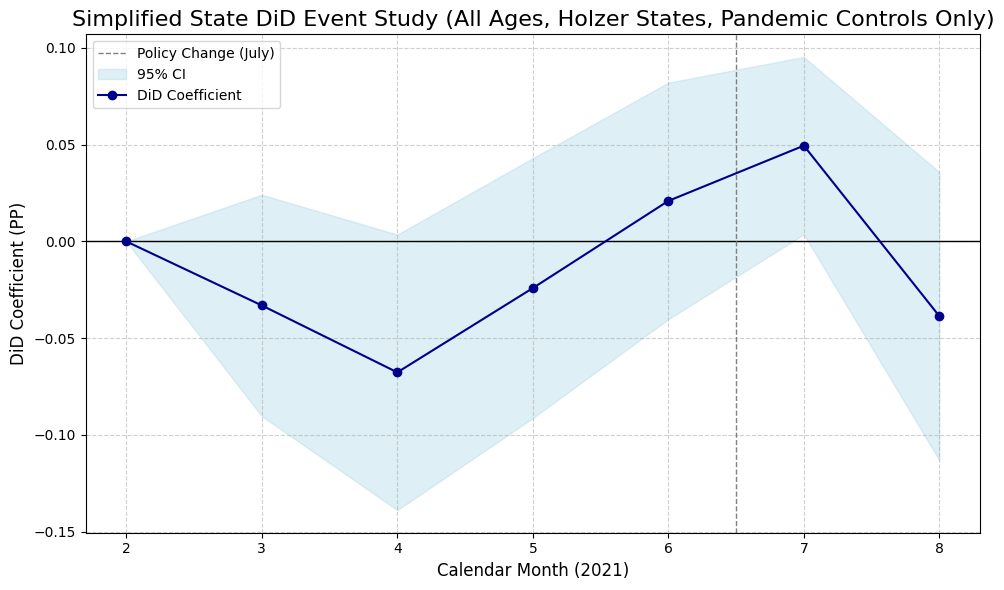

In [32]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH"):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    print(f"Coefficients for: C(TreatState)[T.1]:C({variable}) interactions")
    print(f"Checking PTA: Pre-trend p-values (Months < 7) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    # --- *** MODIFIED REGEX *** ---
    # This pattern now looks for calendar month interactions (e.g., C(MONTH)[T.3])
    # The reference level is defined in the formula (e.g., Treatment(reference=2))
    term_pattern = rf'C\(TreatState\)\[T\.1\]:C\({variable}.*?\)\[T\.(\d+)\]'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var)
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month (e.g., Month 2) with coef=0
    ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in Month 7)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < 7]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< 7) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    # --- *** MODIFIED PLOT *** ---
    # The policy change is now between Month 6 and Month 7
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)')
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    # --- *** MODIFIED AXIS LABEL *** ---
    plt.xlabel("Calendar Month (2021)", fontsize=12)
    plt.ylabel("DiD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DiD analysis for 2021 (All Ages, Holzer States)
    controlling ONLY for COVID cases, stringency, State FE, and Month FE.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # Assuming files are in 'downloads' folder in user's home directory
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        print("Please ensure cps_00004.csv, Policy Milestones - State.csv, COVID - State - Daily.csv, and OxCGRT_US_latest.csv are in your Downloads folder.")
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls ---
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] # Start with cases
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        # FIPS map for OxCGRT 'RegionCode'
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        # --- *** FIX IS HERE *** ---
        # Only append 'avg_stringency' to control_vars IF we successfully created data for it.
        # This prevents the KeyError if monthly_stringency is empty.
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching 2021 state data was found. Skipping stringency.")
        # --- *** END FIX *** ---
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    df_2021 = df[df['YEAR'] == 2021].copy()
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Create date column for merging and relative month calculation
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    
    # Find transitions
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy() # EMPSTAT 20-22 = Unemployed
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # EMPSTAT 10-12 = Employed
    
    # Define Post period (Holzer methodology: July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date']
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT']) # Drop if outcome or next_status is missing
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] # Drop zero weights
    
    print(f"Base 2021 panel (All Ages, Holzer States, Feb-Aug) constructed with {len(final_panel)} observations.")

    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    # This 'if' block is now safe, as is the dropna below
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        
    original_count = len(final_panel_with_controls)
    # This dropna call is now safe. It will only include 'avg_stringency'
    # in control_vars if the merge above was guaranteed to happen.
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DiD Model (Simplified Controls) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DiD (All Ages, Holzer States, State FE + PANDEMIC Controls Only) <<<")
    print("="*80)
    
    # Build formula WITHOUT demographics
    formula_parts = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting simplified DiD model estimation...")
    try:
        model_did = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_did = model_did.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        if 'TreatState:Post' in results_did.params:
            coef_did = results_did.params['TreatState:Post']
            pval_did = results_did.pvalues['TreatState:Post']
            
            print("\n--- Simplified DiD Results (All Ages, Holzer States) ---")
            print(f"Key Coefficient (TreatState:Post): {coef_did:.4f}")
            print(f"P-value: {pval_did:.4f}\n")
            
            # --- *** FIXED PRINTING ERROR HERE *** ---
            # The original code errored with .loc on a SimpleTable
            # This is a safer way to print the key coefficients
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = ['TreatState:Post'] + [v for v in control_vars if v in results_did.params.index]
            for var in key_vars_to_print:
                if var in results_did.params:
                    print(f"{var:<20}: Coef = {results_did.params[var]:>8.4f}, P-val = {results_did.pvalues[var]:.4f}")
                else:
                    print(f"{var:<20}: Not found in model results.")
            # --- *** END FIX *** ---

            print("\n--- Interpretation ---")
            if pval_did < 0.05: print(f"Result: Found a statistically significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            elif pval_did < 0.10: print(f"Result: Found a marginally significant effect ({coef_did:.3f}, p={pval_did:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_did:.3f}).")
            
        else: print("ERROR: 'TreatState:Post' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during simplified DiD estimation: {e}")
        import traceback
        traceback.print_exc()
    
    # --- Step 6: Run Event Study for Validation (Simplified Controls) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on Simplified State DiD Model <<<")
    print("="*80)

    # --- *** MODIFIED: EVENT STUDY IS NOW C(TreatState) * C(MONTH) *** ---
    # This specification correctly tests the parallel trends assumption
    # for the 2x2 DiD model in Step 5.
    # We no longer need the 'relative_month' calculations.
    
    # Build event study formula WITHOUT demographics
    # We use C(MONTH, Treatment(reference=2)) to set Feb as the reference month.
    # We interact this with TreatState.
    # We MUST remove the standalone C(MONTH) fixed effect.
    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2))", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print("\nStarting simplified event study estimation...")
    try:
        # We can use the same dataset as the DiD model
        es_data = final_panel_with_controls.copy()
        
        if es_data.empty:
            print("ERROR: Event study data is empty after processing.")
            return

        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        # Call the helper functions
        plot_df_simplified_did = print_did_event_study_coeffs(results_es, "Simplified_State_DiD_AllAges_HolzerStates", variable="MONTH")
        plot_did_event_study(plot_df_simplified_did, "Simplified State DiD Event Study (All Ages, Holzer States, Pandemic Controls Only)")

    except Exception as e:
        print(f"\nAn error occurred during simplified event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



In [33]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'CollegeGrad')
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    interaction_base = f"C(TreatState)[T.1]:C({variable})"
    if ddd_term:
        # Assumes ddd_term is a 0/1 integer, so it appears as ':{ddd_term}'
        interaction_full = f"C(TreatState)[T.1]:C({variable}).*?[T.(\d+)]:{ddd_term}"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        interaction_full = f"C(TreatState)[T.1]:C({variable}).*?[T.(\d+)]"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < 7) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month (e.g., Month 2) with coef=0
    ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in Month 7)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < 7]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< 7) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)')
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month (2021)", fontsize=12)
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DDD analysis for 2021 (All Ages, Holzer States)
    using EDUC (CollegeGrad) as the differential group.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # Assuming files are in 'downloads' folder in user's home directory
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        print("Please ensure cps_00004.csv, Policy Milestones - State.csv, COVID - State - Daily.csv, and OxCGRT_US_latest.csv are in your Downloads folder.")
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls ---
    # (No changes in this step)
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    covid_2021 = covid_df[df['YEAR'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] # Start with cases
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching 2021 state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    
    # Check for EDUC
    if 'EDUC' not in df.columns:
        print("ERROR: 'EDUC' (Education) not found in cps_00004.csv.")
        print("This variable is required for the CollegeGrad DDD analysis.")
        return
    
    df_2021 = df[df['YEAR'] == 2021].copy()
    
    # --- *** NEW: Define CollegeGrad Group *** ---
    # IPUMS EDUC codes:
    # 111 = Bachelor's degree
    # 123-125 = Master's degree
    # 140 = Doctorate degree
    # We will define CollegeGrad as 1 if EDUC >= 111 (Bachelor's or higher)
    # We must also handle non-applicable codes (e.g., 0)
    df_2021['EDUC'] = pd.to_numeric(df_2021['EDUC'], errors='coerce')
    
    # Create CollegeGrad dummy. Set to NaN if EDUC is 0 or invalid.
    df_2021['CollegeGrad'] = np.nan
    # Only set 0 or 1 where EDUC > 0 (i.e., not NIU)
    df_2021.loc[df_2021['EDUC'] > 0, 'CollegeGrad'] = (df_2021['EDUC'] >= 111).astype(int)
    print(f"Created 'CollegeGrad' variable from 'EDUC'.")
    # --- *** END NEW *** ---
    
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Create date column for merging and relative month calculation
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    
    # Find transitions
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy() # EMPSTAT 20-22 = Unemployed
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # EMPSTAT 10-12 = Employed
    
    # Define Post period (Holzer methodology: July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # --- *** MODIFIED: Add CollegeGrad *** ---
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'CollegeGrad']
    # Drop if outcome, next_status, weight, OR CollegeGrad is missing
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'CollegeGrad']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] # Drop zero weights
    final_panel['CollegeGrad'] = final_panel['CollegeGrad'].astype(int) # Ensure it's 0/1 integer
    
    print(f"Base 2021 panel (Holzer States, Feb-Aug, valid educ) constructed with {len(final_panel)} observations.")
    print(f"Non-Grad (n={len(final_panel[final_panel['CollegeGrad']==0])}), College Grad (n={len(final_panel[final_panel['CollegeGrad']==1])})")


    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (CollegeGrad) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD (All Ages, Holzer States, CollegeGrad) <<<")
    print("="*80)
    
    # --- *** MODIFIED: DDD Formula *** ---
    # Build formula WITHOUT demographics, adding CollegeGrad interaction
    formula_parts = ["found_job ~ TreatState * Post * CollegeGrad", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # --- *** MODIFIED: Look for DDD term *** ---
        ddd_term = 'TreatState:Post:CollegeGrad'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results (All Ages, Holzer States, CollegeGrad) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:CollegeGrad', 'Post:CollegeGrad'] + [v for v in control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
                else:
                    print(f"{var:<25}: Not found in model results.")

            print("\n--- Interpretation ---")
            print(f"This coefficient represents the *additional* effect for College Grads.")
            if pval_ddd < 0.05: print(f"Result: Found a statistically significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            elif pval_ddd < 0.10: print(f"Result: Found a marginally significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_ddd:.3f}). No differential effect found.")
            
        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during DDD estimation: {e}")
        import traceback
        traceback.print_exc()
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on DDD Model (CollegeGrad) <<<")
    print("="*80)

    # --- *** MODIFIED: DDD Event Study Formula *** ---
    # We interact C(TreatState) * C(MONTH) * CollegeGrad
    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * CollegeGrad", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print("\nStarting DDD event study estimation...")
    try:
        # We can use the same dataset as the DiD model
        es_data = final_panel_with_controls.copy()
        
        if es_data.empty:
            print("ERROR: Event study data is empty after processing.")
            return

        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        # --- *** MODIFIED: Call helper with ddd_term *** ---
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            "DDD_State_AllAges_HolzerStates_CollegeGrad", 
            variable="MONTH", 
            ddd_term="CollegeGrad"
        )
        plot_did_event_study(plot_df_ddd, "DDD State Event Study (CollegeGrad vs Non-Grad)")

    except Exception as e:
        print(f"\nAn error occurred during simplified event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()




<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_77712/80276304.py:30: SyntaxWarning: invalid escape sequence '\d'
  interaction_full = f"C(TreatState)[T.1]:C({variable}).*?[T.(\d+)]:{ddd_term}"
/var/folders/95/lqnz31wj1856lzxvq3fhfxmw0000gn/T/ipykernel_77712/80276304.py:33: SyntaxWarning: invalid escape sequence '\d'
  interaction_full = f"C(TreatState)[T.1]:C({variable}).*?[T.(\d+)]"


--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Created 'CollegeGrad' variable from 'EDUC'.
Base 2021 panel (Holzer States, Feb-Aug, valid educ) constructed with 11278 observations.
Non-Grad (n=8350), College Grad (n=2928)

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 0 observations.
ERROR: Panel empty after merging controls.


In [35]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    interaction_base = f"C(TreatState)[T.1]:C({variable})"
    if ddd_term:
        # Assumes ddd_term is a 0/1 integer, so it appears as ':{ddd_term}'
        # --- FIX: Added 'r' to make this a raw f-string ---
        interaction_full = rf"C(TreatState)[T.1]:C({variable}).*?[T.(\d+)]:{ddd_term}"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: Added 'r' to make this a raw f-string ---
        interaction_full = rf"C(TreatState)[T.1]:C({variable}).*?[T.(\d+)]"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < 7) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month (e.g., Month 2) with coef=0
    ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in Month 7)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < 7]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< 7) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)')
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month (2021)", fontsize=12)
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DDD analysis for 2021 (All Ages, Holzer States)
    using IND (LowWage) as the differential group.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # Assuming files are in 'downloads' folder in user's home directory
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        print("Please ensure cps_00004.csv, Policy Milestones - State.csv, COVID - State - Daily.csv, and OxCGRT_US_latest.csv are in your Downloads folder.")
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls ---
    # (No changes in this step)
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    # Filter to 2021 *before* grouping
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] # Start with cases
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching 2021 state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in cps_00004.csv.")
        print("This variable is required for the LowWage DDD analysis.")
        return
    
    df_2021 = df[df['YEAR'] == 2021].copy()
    
    # --- *** NEW: Define LowWage Group based on IND *** ---
    # Using the industry codes from your example:
    # 4670-5780 = Retail Trade (Holzer uses this)
    # 8560-8690 = Accommodation and Food Services (Holzer uses 'Leisure & Hospitality' which includes this)
    # 8660-8700 is a subset of L&H (Arts, Entertainment, and Recreation)
    # We will use the codes provided: (4670 <= x < 5790) OR (8660 <= x < 8700)
    
    df_2021['IND'] = pd.to_numeric(df_2021['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): # Using 8560-8690 for Accom/Food/Arts/Ent
            return 1
        elif x > 0: # Assumes x=0 is NIU or missing
            return 0
        else:
            return np.nan # Return NaN for NIU/missing

    df_2021['LowWage'] = df_2021['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    # --- *** END NEW *** ---
    
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Create date column for merging and relative month calculation
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    
    # Find transitions
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy() # EMPSTAT 20-22 = Unemployed
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # EMPSTAT 10-12 = Employed
    
    # Define Post period (Holzer methodology: July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # --- *** MODIFIED: Add LowWage *** ---
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    # Drop if outcome, next_status, weight, OR LowWage is missing
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] # Drop zero weights
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) # Ensure it's 0/1 integer
    
    print(f"Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")


    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    # --- *** MODIFIED: DDD Formula *** ---
    # Build formula WITHOUT demographics, adding LowWage interaction
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # --- *** MODIFIED: Look for DDD term *** ---
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results (All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
                else:
                    print(f"{var:<25}: Not found in model results.")

            print("\n--- Interpretation ---")
            print(f"This coefficient represents the *additional* effect for the LowWage group.")
            if pval_ddd < 0.05: print(f"Result: Found a statistically significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            elif pval_ddd < 0.10: print(f"Result: Found a marginally significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_ddd:.3f}). No differential effect found.")
            
        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during DDD estimation: {e}")
        import traceback
        traceback.print_exc()
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on DDD Model (LowWage) <<<")
    print("="*80)

    # --- *** MODIFIED: DDD Event Study Formula *** ---
    # We interact C(TreatState) * C(MONTH) * LowWage
    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print("\nStarting DDD event study estimation...")
    try:
        # We can use the same dataset as the DiD model
        es_data = final_panel_with_controls.copy()
        
        if es_data.empty:
            print("ERROR: Event study data is empty after processing.")
            return

        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        # --- *** MODIFIED: Call helper with ddd_term *** ---
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            "DDD_State_AllAges_HolzerStates_LowWage", 
            variable="MONTH", 
            ddd_term="LowWage"
        )
        plot_did_event_study(plot_df_ddd, "DDD State Event Study (LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during simplified event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting DDD model estimation...

--- DDD Results (All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Variables) ---
TreatState:Post:LowWage  : Coef =  -0.0564, P-val = 0.1108
TreatState:Post          : Coef =   0.0485, P-val = 0.0008
TreatState:LowWage       : Coef =   0.0110, P-val

In [37]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    # --- FIX: Make raw string (rf) to fix SyntaxWarning ---
    interaction_base = rf"C(TreatState)\[T\.1\]:C({variable})" # Escaped [ . ]
    if ddd_term:
        # --- FIX: More robust regex to match complex names like ---
        # C(TreatState)[T.1]:C(MONTH, Treatment(reference=2))[T.3]:LowWage
        interaction_full = rf"C(TreatState)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: More robust regex for DiD model, anchored to end ($) ---
        interaction_full = rf"C(TreatState)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < 7) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month (e.g., Month 2) with coef=0
    ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in Month 7)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < 7]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< 7) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)')
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month (2021)", fontsize=12)
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DDD analysis for 2021 (All Ages, Holzer States)
    using IND (LowWage) as the differential group.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # Assuming files are in 'downloads' folder in user's home directory
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        print("Please ensure cps_00004.csv, Policy Milestones - State.csv, COVID - State - Daily.csv, and OxCGRT_US_latest.csv are in your Downloads folder.")
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls ---
    # (No changes in this step)
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    # Filter to 2021 *before* grouping
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] # Start with cases
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching 2021 state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in cps_00004.csv.")
        print("This variable is required for the LowWage DDD analysis.")
        return
    
    df_2021 = df[df['YEAR'] == 2021].copy()
    
    # --- *** NEW: Define LowWage Group based on IND *** ---
    # Using the industry codes from your example:
    # 4670-5780 = Retail Trade (Holzer uses this)
    # 8560-8690 = Accommodation and Food Services (Holzer uses 'Leisure & Hospitality' which includes this)
    # 8660-8700 is a subset of L&H (Arts, Entertainment, and Recreation)
    # We will use the codes provided: (4670 <= x < 5790) OR (8660 <= x < 8700)
    
    df_2021['IND'] = pd.to_numeric(df_2021['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): # Using 8560-8690 for Accom/Food/Arts/Ent
            return 1
        elif x > 0: # Assumes x=0 is NIU or missing
            return 0
        else:
            return np.nan # Return NaN for NIU/missing

    df_2021['LowWage'] = df_2021['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    # --- *** END NEW ---
    
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Create date column for merging and relative month calculation
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    
    # Find transitions
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy() # EMPSTAT 20-22 = Unemployed
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # EMPSTAT 10-12 = Employed
    
    # Define Post period (Holzer methodology: July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # --- *** MODIFIED: Add LowWage *** ---
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    # Drop if outcome, next_status, weight, OR LowWage is missing
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] # Drop zero weights
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) # Ensure it's 0/1 integer
    
    print(f"Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")


    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    # --- *** MODIFIED: DDD Formula *** ---
    # Build formula WITHOUT demographics, adding LowWage interaction
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # --- *** MODIFIED: Look for DDD term ---
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results (All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
                else:
                    print(f"{var:<25}: Not found in model results.")

            print("\n--- Interpretation ---")
            print(f"This coefficient represents the *additional* effect for the LowWage group.")
            if pval_ddd < 0.05: print(f"Result: Found a statistically significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            elif pval_ddd < 0.10: print(f"Result: Found a marginally significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_ddd:.3f}). No differential effect found.")
            
        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during DDD estimation: {e}")
        import traceback
        traceback.print_exc()
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on DDD Model (LowWage) <<<")
    print("="*80)

    # --- *** MODIFIED: DDD Event Study Formula *** ---
    # We interact C(TreatState) * C(MONTH) * LowWage
    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print("\nStarting DDD event study estimation...")
    try:
        # We can use the same dataset as the DiD model
        es_data = final_panel_with_controls.copy()
        
        if es_data.empty:
            print("ERROR: Event study data is empty after processing.")
            return

        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        # --- *** MODIFIED: Call helper with ddd_term ---
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            "DDD_State_AllAges_HolzerStates_LowWage", 
            variable="MONTH", 
            ddd_term="LowWage"
        )
        plot_did_event_study(plot_df_ddd, "DDD State Event Study (LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during simplified event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting DDD model estimation...

--- DDD Results (All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Variables) ---
TreatState:Post:LowWage  : Coef =  -0.0564, P-val = 0.1108
TreatState:Post          : Coef =   0.0485, P-val = 0.0008
TreatState:LowWage       : Coef =   0.0110, P-val

In [38]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    interaction_base = rf"C(TreatState)\[T\.1\]:C({variable})" # Escaped [ . ]
    if ddd_term:
        # --- FIX: Anchored the ddd_term to the end of the string ($) ---
        # This ensures we match '...[T.3]:LowWage' and not '...[T.3]:LowWage:SomeOtherTerm'
        interaction_full = rf"C(TreatState)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}$"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # This regex (for 2x2 DiD) was already correct and anchored
        interaction_full = rf"C(TreatState)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < 7) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month (e.g., Month 2) with coef=0
    ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in Month 7)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < 7]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< 7) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)')
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month (2021)", fontsize=12)
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DDD analysis for 2021 (All Ages, Holzer States)
    using IND (LowWage) as the differential group.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # Assuming files are in 'downloads' folder in user's home directory
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        print("Please ensure cps_00004.csv, Policy Milestones - State.csv, COVID - State - Daily.csv, and OxCGRT_US_latest.csv are in your Downloads folder.")
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls ---
    # (No changes in this step)
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    # Filter to 2021 *before* grouping
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] # Start with cases
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching 2021 state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in cps_00004.csv.")
        print("This variable is required for the LowWage DDD analysis.")
        return
    
    df_2021 = df[df['YEAR'] == 2021].copy()
    
    # --- *** NEW: Define LowWage Group based on IND *** ---
    # Using the industry codes from your example:
    # 4670-5780 = Retail Trade (Holzer uses this)
    # 8560-8690 = Accommodation and Food Services (Holzer uses 'Leisure & Hospitality' which includes this)
    # 8660-8700 is a subset of L&H (Arts, Entertainment, and Recreation)
    # We will use the codes provided: (4670 <= x < 5790) OR (8660 <= x < 8700)
    
    df_2021['IND'] = pd.to_numeric(df_2021['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): # Using 8560-8690 for Accom/Food/Arts/Ent
            return 1
        elif x > 0: # Assumes x=0 is NIU or missing
            return 0
        else:
            return np.nan # Return NaN for NIU/missing

    df_2021['LowWage'] = df_2021['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    # --- *** END NEW ---
    
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Create date column for merging and relative month calculation
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    
    # Find transitions
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy() # EMPSTAT 20-22 = Unemployed
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # EMPSTAT 10-12 = Employed
    
    # Define Post period (Holzer methodology: July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # --- *** MODIFIED: Add LowWage *** ---
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    # Drop if outcome, next_status, weight, OR LowWage is missing
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] # Drop zero weights
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) # Ensure it's 0/1 integer
    
    print(f"Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")


    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    # --- *** MODIFIED: DDD Formula *** ---
    # Build formula WITHOUT demographics, adding LowWage interaction
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # --- *** MODIFIED: Look for DDD term ---
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results (All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
                else:
                    print(f"{var:<25}: Not found in model results.")

            print("\n--- Interpretation ---")
            print(f"This coefficient represents the *additional* effect for the LowWage group.")
            if pval_ddd < 0.05: print(f"Result: Found a statistically significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            elif pval_ddd < 0.10: print(f"Result: Found a marginally significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_ddd:.3f}). No differential effect found.")
            
        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during DDD estimation: {e}")
        import traceback
        traceback.print_exc()
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on DDD Model (LowWage) <<<")
    print("="*80)

    # --- *** MODIFIED: DDD Event Study Formula *** ---
    # We interact C(TreatState) * C(MONTH) * LowWage
    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print("\nStarting DDD event study estimation...")
    try:
        # We can use the same dataset as the DiD model
        es_data = final_panel_with_controls.copy()
        
        if es_data.empty:
            print("ERROR: Event study data is empty after processing.")
            return

        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        # --- *** MODIFIED: Call helper with ddd_term ---
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            "DDD_State_AllAges_HolzerStates_LowWage", 
            variable="MONTH", 
            ddd_term="LowWage"
        )
        plot_did_event_study(plot_df_ddd, "DDD State Event Study (LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during simplified event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting DDD model estimation...

--- DDD Results (All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Variables) ---
TreatState:Post:LowWage  : Coef =  -0.0564, P-val = 0.1108
TreatState:Post          : Coef =   0.0485, P-val = 0.0008
TreatState:LowWage       : Coef =   0.0110, P-val

--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting DDD model estimation...

--- DDD Results (All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Variables) ---
TreatState:Post:LowWage  : Coef =  -0.0564, P-val = 0.1108
TreatState:Post          : Coef =   0.0485, P-val = 0.0008
TreatState:LowWage       : Coef =   0.0110, P-val

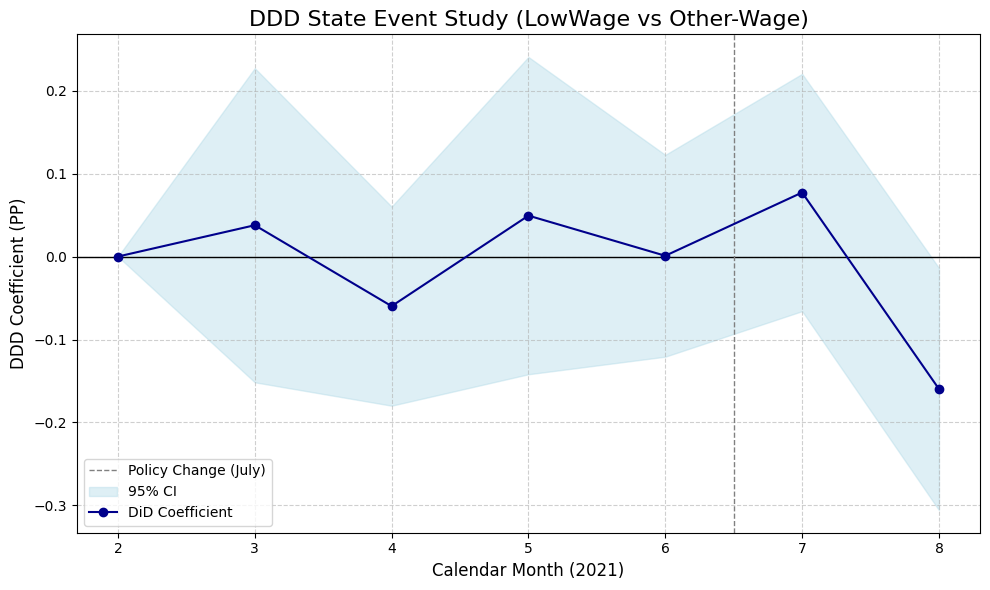

In [39]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    # --- FIX: Escape parentheses in C(TreatState) ---
    interaction_base = rf"C\(TreatState\)\[T\.1\]:C({variable})" # Escaped ( ) [ . ]
    if ddd_term:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}$"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < 7) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month (e.g., Month 2) with coef=0
    ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in Month 7)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < 7]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< 7) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)')
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month (2021)", fontsize=12)
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DDD analysis for 2021 (All Ages, Holzer States)
    using IND (LowWage) as the differential group.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # Assuming files are in 'downloads' folder in user's home directory
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        print("Please ensure cps_00004.csv, Policy Milestones - State.csv, COVID - State - Daily.csv, and OxCGRT_US_latest.csv are in your Downloads folder.")
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls ---
    # (No changes in this step)
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    # Filter to 2021 *before* grouping
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] # Start with cases
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching 2021 state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in cps_00004.csv.")
        print("This variable is required for the LowWage DDD analysis.")
        return
    
    df_2021 = df[df['YEAR'] == 2021].copy()
    
    # --- *** NEW: Define LowWage Group based on IND *** ---
    # Using the industry codes from your example:
    # 4670-5780 = Retail Trade (Holzer uses this)
    # 8560-8690 = Accommodation and Food Services (Holzer uses 'Leisure & Hospitality' which includes this)
    # 8660-8700 is a subset of L&H (Arts, Entertainment, and Recreation)
    # We will use the codes provided: (4670 <= x < 5790) OR (8660 <= x < 8700)
    
    df_2021['IND'] = pd.to_numeric(df_2021['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): # Using 8560-8690 for Accom/Food/Arts/Ent
            return 1
        elif x > 0: # Assumes x=0 is NIU or missing
            return 0
        else:
            return np.nan # Return NaN for NIU/missing

    df_2021['LowWage'] = df_2021['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    # --- *** END NEW ---
    
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Create date column for merging and relative month calculation
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    
    # Find transitions
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy() # EMPSTAT 20-22 = Unemployed
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # EMPSTAT 10-12 = Employed
    
    # Define Post period (Holzer methodology: July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # --- *** MODIFIED: Add LowWage *** ---
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    # Drop if outcome, next_status, weight, OR LowWage is missing
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] # Drop zero weights
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) # Ensure it's 0/1 integer
    
    print(f"Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")


    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    # --- *** MODIFIED: DDD Formula *** ---
    # Build formula WITHOUT demographics, adding LowWage interaction
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # --- *** MODIFIED: Look for DDD term ---
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results (All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
                else:
                    print(f"{var:<25}: Not found in model results.")

            print("\n--- Interpretation ---")
            print(f"This coefficient represents the *additional* effect for the LowWage group.")
            if pval_ddd < 0.05: print(f"Result: Found a statistically significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            elif pval_ddd < 0.10: print(f"Result: Found a marginally significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_ddd:.3f}). No differential effect found.")
            
        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during DDD estimation: {e}")
        import traceback
        traceback.print_exc()
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on DDD Model (LowWage) <<<")
    print("="*80)

    # --- *** MODIFIED: DDD Event Study Formula *** ---
    # We interact C(TreatState) * C(MONTH) * LowWage
    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print("\nStarting DDD event study estimation...")
    try:
        # We can use the same dataset as the DiD model
        es_data = final_panel_with_controls.copy()
        
        if es_data.empty:
            print("ERROR: Event study data is empty after processing.")
            return

        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        # --- *** MODIFIED: Call helper with ddd_term ---
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            "DDD_State_AllAges_HolzerStates_LowWage", 
            variable="MONTH", 
            ddd_term="LowWage"
        )
        plot_did_event_study(plot_df_ddd, "DDD State Event Study (LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during simplified event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls ---
Controls prepared.

--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into panel ---
Final panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting DDD model estimation...

--- DDD Results (All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Variables) ---
TreatState:Post:LowWage  : Coef =  -0.0564, P-val = 0.1108
TreatState:Post          : Coef =   0.0485, P-val = 0.0008
TreatState:LowWage       : Coef =   0.0110, P-val

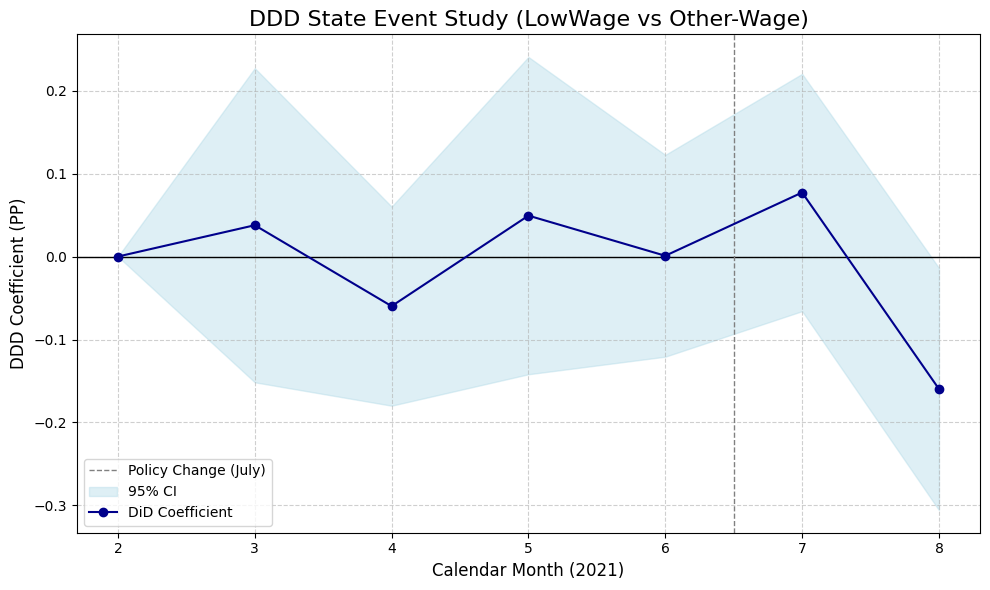

In [40]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    # --- FIX: Escape parentheses in C(TreatState) ---
    interaction_base = rf"C\(TreatState\)\[T\.1\]:C({variable})" # Escaped ( ) [ . ]
    if ddd_term:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}$"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < 7) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month (e.g., Month 2) with coef=0
    ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
    plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in Month 7)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < 7]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< 7) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)')
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month (2021)", fontsize=12)
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Runs the state-level DDD analysis for 2021 (All Ages, Holzer States)
    using IND (LowWage) as the differential group.
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        # Assuming files are in 'downloads' folder in user's home directory
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        df = pd.read_csv(cps_path); policy_df = pd.read_csv(policy_path, parse_dates=['date'])
        covid_df = pd.read_csv(covid_path, na_values='.'); ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        print("Please ensure cps_00004.csv, Policy Milestones - State.csv, COVID - State - Daily.csv, and OxCGRT_US_latest.csv are in your Downloads folder.")
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls ---
    # (No changes in this step)
    print("\n--- Step 2: Preparing Controls ---")
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    # Filter to 2021 *before* grouping
    covid_2021 = covid_df[covid_df['year'] == 2021].copy()
    monthly_covid = covid_2021.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] # Start with cases
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'] == 2021)].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching 2021 state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Step 3: Prepare Final 2021 STATE Panel (All Ages, Holzer States) ---
    print("\n--- Step 3: Preparing Final 2021 STATE Panel (All Ages, Holzer States) ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in cps_00004.csv.")
        print("This variable is required for the LowWage DDD analysis.")
        return
    
    df_2021 = df[df['YEAR'] == 2021].copy()
    
    # --- *** NEW: Define LowWage Group based on IND *** ---
    # Using the industry codes from your example:
    # 4670-5780 = Retail Trade (Holzer uses this)
    # 8560-8690 = Accommodation and Food Services (Holzer uses 'Leisure & Hospitality' which includes this)
    # 8660-8700 is a subset of L&H (Arts, Entertainment, and Recreation)
    # We will use the codes provided: (4670 <= x < 5790) OR (8660 <= x < 8700)
    
    df_2021['IND'] = pd.to_numeric(df_2021['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): # Using 8560-8690 for Accom/Food/Arts/Ent
            return 1
        elif x > 0: # Assumes x=0 is NIU or missing
            return 0
        else:
            return np.nan # Return NaN for NIU/missing

    df_2021['LowWage'] = df_2021['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    # --- *** END NEW ---
    
    df_2021 = df_2021[df_2021['STATEFIP'].isin(included_states)].copy()
    df_2021['TreatState'] = df_2021['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    
    # Create date column for merging and relative month calculation
    df_2021['date'] = pd.to_datetime(df_2021['YEAR'].astype(str) + '-' + df_2021['MONTH'].astype(str) + '-01')
    
    # Find transitions
    df_2021.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_2021['status_next_month'] = df_2021.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_2021[df_2021['EMPSTAT'].between(20, 22)].copy() # EMPSTAT 20-22 = Unemployed
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) # EMPSTAT 10-12 = Employed
    
    # Define Post period (Holzer methodology: July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= 7) & (unemployed_df['MONTH'] <= 8)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # --- *** MODIFIED: Add LowWage *** ---
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    # Drop if outcome, next_status, weight, OR LowWage is missing
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] # Drop zero weights
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) # Ensure it's 0/1 integer
    
    print(f"Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")


    # --- Step 4: Merge Controls ---
    print("\n--- Step 4: Merging Controls into panel ---")
    final_panel_with_controls = pd.merge(final_panel, monthly_covid, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    if not monthly_stringency.empty:
        final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print("ERROR: Panel empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(">>> FINAL MODEL: DDD (All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    # --- *** MODIFIED: DDD Formula *** ---
    # Build formula WITHOUT demographics, adding LowWage interaction
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print("\nStarting DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        # --- *** MODIFIED: Look for DDD term ---
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results (All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
                else:
                    print(f"{var:<25}: Not found in model results.")

            print("\n--- Interpretation ---")
            print(f"This coefficient represents the *additional* effect for the LowWage group.")
            if pval_ddd < 0.05: print(f"Result: Found a statistically significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            elif pval_ddd < 0.10: print(f"Result: Found a marginally significant *differential* effect ({coef_ddd:.3f}, p={pval_ddd:.3f}).")
            else: print(f"Result: Effect is NOT statistically significant (p={pval_ddd:.3f}). No differential effect found.")
            
        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during DDD estimation: {e}")
        import traceback
        traceback.print_exc()

    # --- *** NEW: Step 5b: Run Separate DiD Models by Wage Group *** ---
    print("\n" + "="*80)
    print(">>> Step 5b: Separate 2x2 DiD Models by Wage Group <<<")
    print("="*80)
    
    # 1. Create subset panels
    other_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 0].copy()
    low_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 1].copy()
    print(f"Running DiD for Other Wage group (n={len(other_wage_panel)})")
    print(f"Running DiD for Low Wage group (n={len(low_wage_panel)})")

    # 2. Define the simple DiD formula
    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(2, "avg_stringency")
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    # 3. Run DiD for OTHER WAGE (High Wage)
    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=other_wage_panel, weights=other_wage_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': other_wage_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print("\n--- DiD Results for OTHER WAGE Group (LowWage=0) ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.05: print("Result: Statistically SIGNIFICANT effect.")
        else: print("Result: NOT statistically significant.")
        
    except Exception as e:
        print(f"\nAn error occurred during Other Wage DiD estimation: {e}")

    # 4. Run DiD for LOW WAGE
    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print("\n--- DiD Results for LOW WAGE Group (LowWage=1) ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.05: print("Result: Statistically SIGNIFICANT effect.")
        else: print("Result: NOT statistically significant.")
        
    except Exception as e:
        print(f"\nAn error occurred during Low Wage DiD estimation: {e}")
    # --- *** END NEW STEP *** ---
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(">>> VALIDATION: Event Study on DDD Model (LowWage) <<<")
    print("="*80)

    # --- *** MODIFIED: DDD Event Study Formula *** ---
    # We interact C(TreatState) * C(MONTH) * LowWage
    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print("\nStarting DDD event study estimation...")
    try:
        # We can use the same dataset as the DiD model
        es_data = final_panel_with_controls.copy()
        
        if es_data.empty:
            print("ERROR: Event study data is empty after processing.")
            return

        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        # --- *** MODIFIED: Call helper with ddd_term ---
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            "DDD_State_AllAges_HolzerStates_LowWage", 
            variable="MONTH", 
            ddd_term="LowWage"
        )
        plot_did_event_study(plot_df_ddd, "DDD State Event Study (LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during simplified event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.

--- Step 2: Preparing Controls (All Years) ---
Controls prepared.

--- RUNNING ANALYSIS FOR YEAR: 2021 ---

--- Step 3: Preparing Final 2021 STATE Panel ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into 2021 panel ---
Final 2021 panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (2021, All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting 2021 DDD model estimation...

--- DDD Results (2021, All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Variables) ---
TreatState:Post:LowWage  : Coef =  -0.0564, P-val = 0.1108
TreatState:Post          : Coef =   0.0485, P-val = 0.

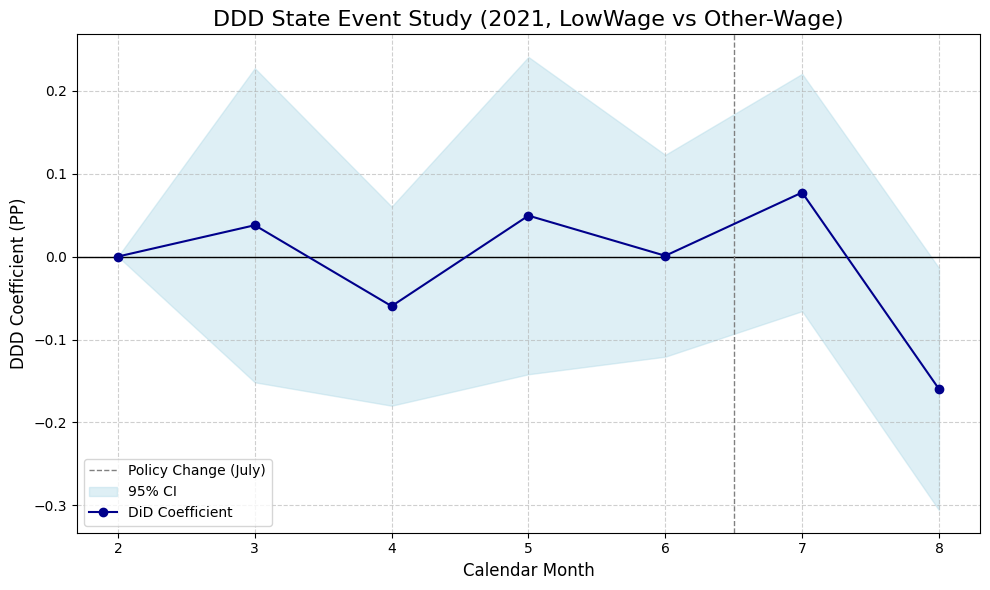


--- RUNNING ANALYSIS FOR YEAR: 2019 ---

--- Step 3: Preparing Final 2019 STATE Panel ---
ERROR: No data found for 2019.


In [41]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None, policy_month=7):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    'policy_month' is the first month of the post-period (e.g., 7 for July)
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    # --- FIX: Escape parentheses in C(TreatState) ---
    interaction_base = rf"C\(TreatState\)\[T\.1\]:C({variable})" # Escaped ( ) [ . ]
    if ddd_term:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}$"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < {policy_month}) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month with coef=0
    if ref_month not in est_df['relative_month'].values:
        ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
        plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    else:
        plot_df = est_df.copy()
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in policy_month)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < policy_month]['pval']
    if pre_trend_pvals.empty:
        print("No pre-trends (< {policy_month}) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)') # Keep as July for comparison
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month", fontsize=12) # Generic x-axis label
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_analysis(df, year, holzer_treat_fips, holzer_control_fips, monthly_covid, monthly_stringency, control_vars, policy_month=7):
    """
    Main analysis function to be run for 2021 (main) and 2019 (placebo).
    """
    
    print("\n" + "="*80)
    print(f"--- RUNNING ANALYSIS FOR YEAR: {year} ---")
    print("="*80)

    # --- Step 3: Prepare Final STATE Panel ---
    print(f"\n--- Step 3: Preparing Final {year} STATE Panel ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in cps_00004.csv.")
        return
    
    df_year = df[df['YEAR'] == year].copy()
    if df_year.empty:
        print(f"ERROR: No data found for {year}.")
        return
    
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- *** MODIFIED: Define LowWage Group based on IND *** ---
    df_year['IND'] = pd.to_numeric(df_year['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): 
            return 1
        elif x > 0: 
            return 0
        else:
            return np.nan 

    df_year['LowWage'] = df_year['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    
    df_year = df_year[df_year['STATEFIP'].isin(included_states)].copy()
    df_year['TreatState'] = df_year['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_year['date'] = pd.to_datetime(df_year['YEAR'].astype(str) + '-' + df_year['MONTH'].astype(str) + '-01')
    
    df_year.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_year['status_next_month'] = df_year.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_year[df_year['EMPSTAT'].between(20, 22)].copy() 
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) 
    
    # Define Post period (July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= policy_month) & (unemployed_df['MONTH'] <= policy_month + 1)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] 
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) 
    
    print(f"Base {year} panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")

    # --- Step 4: Merge Controls ---
    print(f"\n--- Step 4: Merging Controls into {year} panel ---")
    
    # Filter controls for the specific year
    monthly_covid_year = monthly_covid[monthly_covid['YEAR'] == year]
    
    final_panel_with_controls = pd.merge(final_panel, monthly_covid_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    
    current_control_vars = ['log_monthly_cases'] # Start with cases
    
    if not monthly_stringency.empty:
        monthly_stringency_year = monthly_stringency[monthly_stringency['YEAR'] == year]
        if not monthly_stringency_year.empty:
            final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
            current_control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=current_control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final {year} panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print(f"ERROR: Panel for {year} is empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(f">>> FINAL MODEL: DDD ({year}, All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print(f"\nStarting {year} DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results ({year}, All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in current_control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
            
            print("\n--- Interpretation ---")
            if year == 2019:
                if pval_ddd < 0.10: print(f"PLACEBO TEST FAILED: Found a significant effect (p={pval_ddd:.3f}) in placebo year.")
                else: print(f"PLACEBO TEST PASSED: No significant effect found (p={pval_ddd:.3f}).")
            else:
                if pval_ddd < 0.10: print(f"Result: Found a statistically significant differential effect (p={pval_ddd:.3f}).")
                else: print(f"Result: No statistically significant differential effect found (p={pval_ddd:.3f}).")

        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during {year} DDD estimation: {e}")

    # --- Step 5b: Run Separate DiD Models by Wage Group ---
    print("\n" + "="*80)
    print(f">>> Step 5b: Separate 2x2 DiD Models by Wage Group ({year}) <<<")
    print("="*80)
    
    other_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 0].copy()
    low_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 1].copy()
    print(f"Running DiD for Other Wage group (n={len(other_wage_panel)})")
    print(f"Running DiD for Low Wage group (n={len(low_wage_panel)})")

    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(2, "avg_stringency")
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=other_wage_panel, weights=other_wage_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': other_wage_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for OTHER WAGE Group (LowWage=0) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_other:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_other:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Other Wage DiD estimation: {e}")

    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for LOW WAGE Group (LowWage=1) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_low:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_low:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Low Wage DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(f">>> VALIDATION: Event Study on DDD Model (LowWage) ({year}) <<<")
    print("="*80)

    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print(f"\nStarting {year} DDD event study estimation...")
    try:
        es_data = final_panel_with_controls.copy()
        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            f"DDD_State_AllAges_HolzerStates_LowWage_{year}", 
            variable="MONTH", 
            ddd_term="LowWage",
            policy_month=policy_month
        )
        plot_did_event_study(plot_df_ddd, f"DDD State Event Study ({year}, LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during {year} event study estimation: {e}")
        import traceback
        traceback.print_exc()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Main function to load data and run analysis for 2021 and 2019 (placebo).
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        # Load CPS data (main file)
        df = pd.read_csv(cps_path) 
        # policy_df = pd.read_csv(policy_path, parse_dates=['date']) # Not needed for 2x2
        
        # Load controls (all years)
        covid_df = pd.read_csv(covid_path, na_values='.'); 
        ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        print("All data loaded successfully.")
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls (All Years) ---
    print("\n--- Step 2: Preparing Controls (All Years) ---")
    
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    monthly_covid = covid_df.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] 
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        # Filter to relevant years (2019, 2021)
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'].isin([2019, 2021]))].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            control_vars.append('avg_stringency')
        else:
            print("Warning: OxCGRT data was processed, but no matching state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Run Main Analysis for 2021 ---
    run_state_did_analysis(
        df=df, 
        year=2021, 
        holzer_treat_fips=holzer_treat_fips, 
        holzer_control_fips=holzer_control_fips, 
        monthly_covid=monthly_covid, 
        monthly_stringency=monthly_stringency,
        control_vars=control_vars,
        policy_month=7 # Policy starts in July
    )
    
    # --- Run Placebo Test for 2019 ---
    run_state_did_analysis(
        df=df, 
        year=2019, 
        holzer_treat_fips=holzer_treat_fips, 
        holzer_control_fips=holzer_control_fips, 
        monthly_covid=monthly_covid, 
        monthly_stringency=monthly_stringency,
        control_vars=control_vars,
        policy_month=7 # Placebo policy starts in July
    )


# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.
Available years found in cps_00004.csv: [np.int64(2020), np.int64(2021)]

--- Step 2: Preparing Controls (All Years) ---
Controls prepared.

--- RUNNING ANALYSIS FOR YEAR: 2021 ---

--- Step 3: Preparing Final 2021 STATE Panel ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into 2021 panel ---
Final 2021 panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (2021, All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting 2021 DDD model estimation...

--- DDD Results (2021, All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Variables) ---
TreatState:Post:LowWage  : Coef =  -0.05

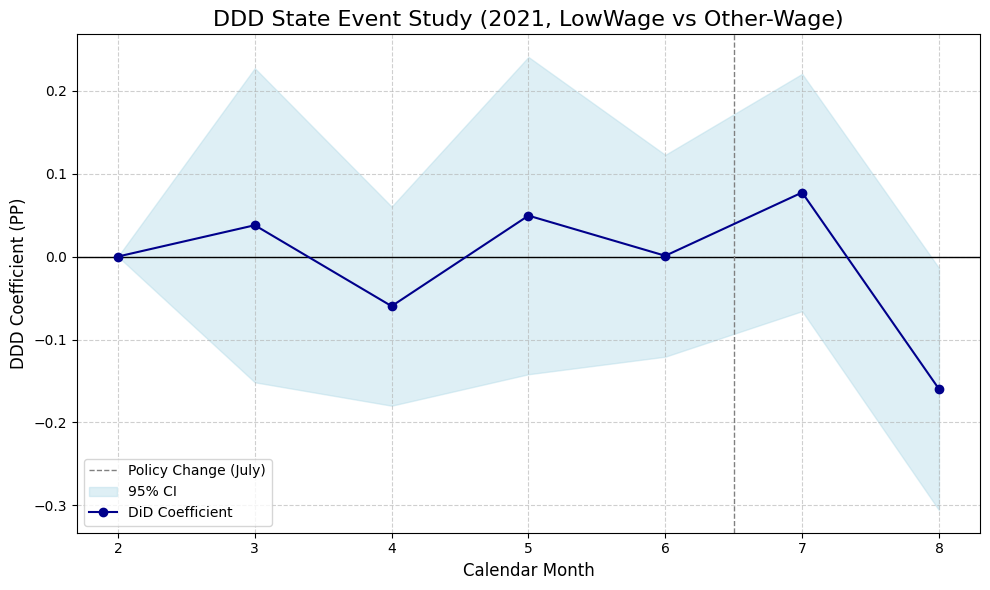


Note: 2020 data is available, but it is unsuitable for a placebo test due to the COVID-19 pandemic.


In [43]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None, policy_month=7):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    'policy_month' is the first month of the post-period (e.g., 7 for July)
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    # --- FIX: Escape parentheses in C(TreatState) ---
    interaction_base = rf"C\(TreatState\)\[T\.1\]:C({variable})" # Escaped ( ) [ . ]
    if ddd_term:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}$"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < {policy_month}) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month with coef=0
    if ref_month not in est_df['relative_month'].values:
        ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
        plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    else:
        plot_df = est_df.copy()
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in policy_month)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < policy_month]['pval']
    if pre_trend_pvals.empty:
        print(f"No pre-trends (< {policy_month}) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)') # Keep as July for comparison
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month", fontsize=12) # Generic x-axis label
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_analysis(df, year, holzer_treat_fips, holzer_control_fips, monthly_covid, monthly_stringency, control_vars, policy_month=7):
    """
    Main analysis function to be run for 2021 (main) and 2019 (placebo).
    """
    
    print("\n" + "="*80)
    print(f"--- RUNNING ANALYSIS FOR YEAR: {year} ---")
    print("="*80)

    # --- Step 3: Prepare Final STATE Panel ---
    print(f"\n--- Step 3: Preparing Final {year} STATE Panel ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in cps_00004.csv.")
        return
    
    df_year = df[df['YEAR'] == year].copy()
    if df_year.empty:
        print(f"ERROR: No data found for {year}.")
        return
    
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- *** MODIFIED: Define LowWage Group based on IND *** ---
    df_year['IND'] = pd.to_numeric(df_year['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): 
            return 1
        elif x > 0: 
            return 0
        else:
            return np.nan 

    df_year['LowWage'] = df_year['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    
    df_year = df_year[df_year['STATEFIP'].isin(included_states)].copy()
    df_year['TreatState'] = df_year['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_year['date'] = pd.to_datetime(df_year['YEAR'].astype(str) + '-' + df_year['MONTH'].astype(str) + '-01')
    
    df_year.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_year['status_next_month'] = df_year.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_year[df_year['EMPSTAT'].between(20, 22)].copy() 
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) 
    
    # Define Post period (July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= policy_month) & (unemployed_df['MONTH'] <= policy_month + 1)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] 
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) 
    
    print(f"Base {year} panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")

    # --- Step 4: Merge Controls ---
    print(f"\n--- Step 4: Merging Controls into {year} panel ---")
    
    # Filter controls for the specific year
    monthly_covid_year = monthly_covid[monthly_covid['YEAR'] == year]
    
    final_panel_with_controls = pd.merge(final_panel, monthly_covid_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    
    current_control_vars = ['log_monthly_cases'] # Start with cases
    
    if not monthly_stringency.empty:
        monthly_stringency_year = monthly_stringency[monthly_stringency['YEAR'] == year]
        if not monthly_stringency_year.empty:
            final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
            current_control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=current_control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final {year} panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print(f"ERROR: Panel for {year} is empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(f">>> FINAL MODEL: DDD ({year}, All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print(f"\nStarting {year} DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results ({year}, All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in current_control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
            
            print("\n--- Interpretation ---")
            if year == 2019:
                if pval_ddd < 0.10: print(f"PLACEBO TEST FAILED: Found a significant effect (p={pval_ddd:.3f}) in placebo year.")
                else: print(f"PLACEBO TEST PASSED: No significant effect found (p={pval_ddd:.3f}).")
            else:
                if pval_ddd < 0.10: print(f"Result: Found a statistically significant differential effect (p={pval_ddd:.3f}).")
                else: print(f"Result: No statistically significant differential effect found (p={pval_ddd:.3f}).")

        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during {year} DDD estimation: {e}")

    # --- Step 5b: Run Separate DiD Models by Wage Group ---
    print("\n" + "="*80)
    print(f">>> Step 5b: Separate 2x2 DiD Models by Wage Group ({year}) <<<")
    print("="*80)
    
    other_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 0].copy()
    low_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 1].copy()
    print(f"Running DiD for Other Wage group (n={len(other_wage_panel)})")
    print(f"Running DiD for Low Wage group (n={len(low_wage_panel)})")

    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(2, "avg_stringency")
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=other_wage_panel, weights=other_wage_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': other_wage_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for OTHER WAGE Group (LowWage=0) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_other:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_other:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Other Wage DiD estimation: {e}")

    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for LOW WAGE Group (LowWage=1) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_low:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_low:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Low Wage DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(f">>> VALIDATION: Event Study on DDD Model (LowWage) ({year}) <<<")
    print("="*80)

    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print(f"\nStarting {year} DDD event study estimation...")
    try:
        es_data = final_panel_with_controls.copy()
        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            f"DDD_State_AllAges_HolzerStates_LowWage_{year}", 
            variable="MONTH", 
            ddd_term="LowWage",
            policy_month=policy_month
        )
        plot_did_event_study(plot_df_ddd, f"DDD State Event Study ({year}, LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during {year} event study estimation: {e}")
        import traceback
        traceback.print_exc()


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Main function to load data and run analysis for 2021 and placebo year (if available).
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        # Load CPS data (main file)
        df = pd.read_csv(cps_path) 
        # policy_df = pd.read_csv(policy_path, parse_dates=['date']) # Not needed for 2x2
        
        # Load controls (all years)
        covid_df = pd.read_csv(covid_path, na_values='.'); 
        ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        
        # --- *** NEW: Check available years *** ---
        available_years = sorted(df['YEAR'].unique())
        print(f"All data loaded successfully.")
        print(f"Available years found in {cps_file}: {available_years}")
        # --- *** END NEW *** ---

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls (All Years) ---
    print("\n--- Step 2: Preparing Controls (All Years) ---")
    
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    monthly_covid = covid_df.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] 
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        # Filter to relevant years
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'].isin(available_years))].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            # Check if we have data for our specific years of interest
            if 2021 in monthly_stringency['YEAR'].unique() or 2019 in monthly_stringency['YEAR'].unique():
                 control_vars.append('avg_stringency')
            else:
                print("Warning: OxCGRT data processed, but no matching 2019 or 2021 state data found. Skipping stringency.")
        else:
            print("Warning: OxCGRT data was processed, but no matching state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Run Main Analysis for 2021 ---
    if 2021 in available_years:
        run_state_did_analysis(
            df=df, 
            year=2021, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("ERROR: Year 2021 not found in CPS data. Cannot run main analysis.")
        print("="*80)

    
    # --- Run Placebo Test for 2019 ---
    if 2019 in available_years:
        run_state_did_analysis(
            df=df, 
            year=2019, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Placebo policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("WARNING: Year 2019 not found in CPS data. Skipping 2019 Placebo Test.")
        if 2020 in available_years:
            print("Note: 2020 data is available, but it is unsuitable for a placebo test due to the COVID-19 pandemic.")
        print("="*80)


# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.
Available years found in cps_00004.csv: [np.int64(2020), np.int64(2021)]

--- Step 2: Preparing Controls (All Years) ---
Controls prepared.

--- RUNNING MAIN ANALYSIS (LowWage) FOR YEAR: 2021 ---

--- Step 3: Preparing Final 2021 STATE Panel (LowWage) ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into 2021 panel (LowWage) ---
Final 2021 panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (2021, All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting 2021 DDD model estimation...

--- DDD Results (2021, All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Variables) ---
Treat

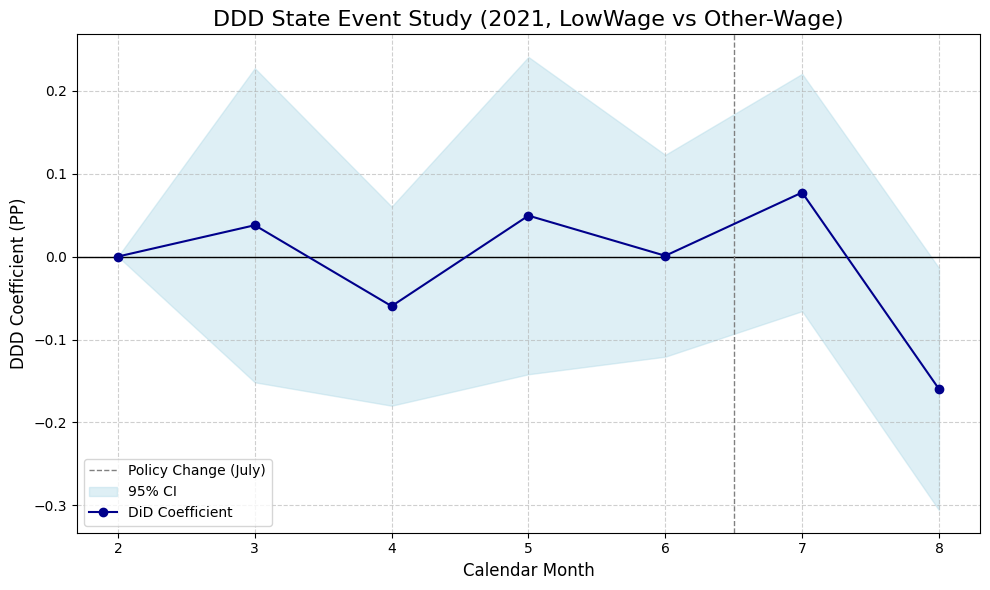


Note: 2020 data is available, but it is unsuitable for a placebo test due to the COVID-19 pandemic.

--- RUNNING SENSITIVITY TEST (CollegeGrad) FOR YEAR: 2021 ---

--- Step 3: Preparing Final 2021 STATE Panel (CollegeGrad) ---
Created 'CollegeGrad' variable from 'EDUC'.
Base 2021 panel (Holzer States, Feb-Aug, valid education) constructed with 11278 observations.
Not College Grad (n=8350), College Grad (n=2928)

--- Step 4: Merging Controls into 2021 panel (CollegeGrad) ---
Final 2021 panel with controls constructed with 11278 observations.

>>> SENSITIVITY MODEL: DDD (2021, All Ages, Holzer States, CollegeGrad) <<<
Using formula:
found_job ~ TreatState * Post * CollegeGrad + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting 2021 DDD model estimation...

--- DDD Results (2021, All Ages, Holzer States, CollegeGrad) ---
Key Coefficient (TreatState:Post:CollegeGrad): 0.0212
P-value: 0.7429

--- Coefficient Summary (Key Variables) ---
TreatState:Post:CollegeGrad: Coef =   0.0212, P-val

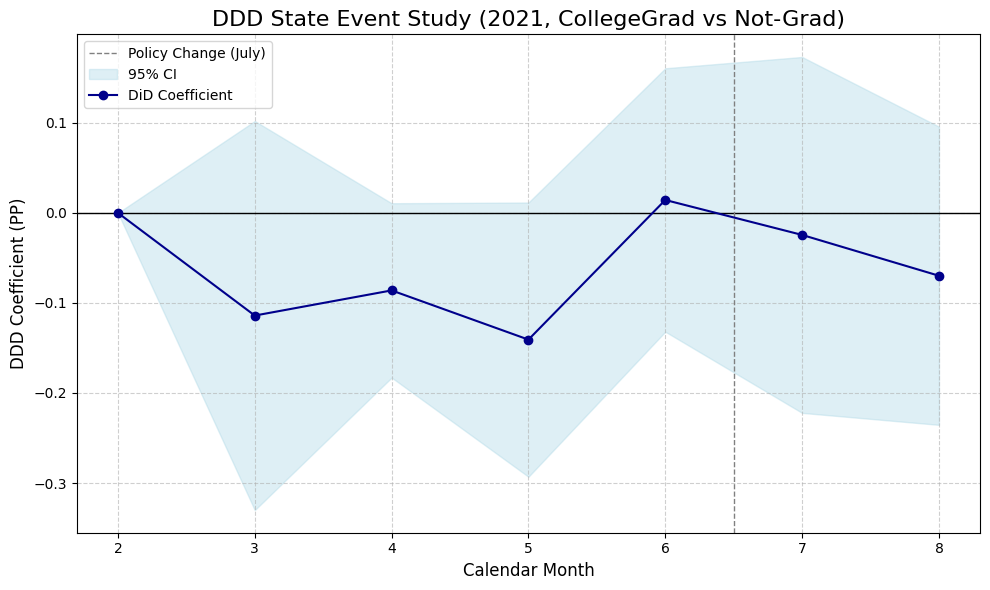

In [44]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

# --- Helper Function to Print Coefficients (DiD Event Study) ---
def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None, policy_month=7):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    'policy_month' is the first month of the post-period (e.g., 7 for July)
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    # --- FIX: Escape parentheses in C(TreatState) ---
    interaction_base = rf"C\(TreatState\)\[T\.1\]:C({variable})" # Escaped ( ) [ . ]
    if ddd_term:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}$"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < {policy_month}) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month with coef=0
    if ref_month not in est_df['relative_month'].values:
        ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
        plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    else:
        plot_df = est_df.copy()
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in policy_month)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < policy_month]['pval']
    if pre_trend_pvals.empty:
        print(f"No pre-trends (< {policy_month}) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

# --- Helper Function to Plot Event Study (DiD) ---
def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)') # Keep as July for comparison
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month", fontsize=12) # Generic x-axis label
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()


def run_state_did_analysis(df, year, holzer_treat_fips, holzer_control_fips, monthly_covid, monthly_stringency, control_vars, policy_month=7):
    """
    Main analysis function for 2021 (main) and 2019 (placebo) using LOWWAGE (industry).
    """
    
    print("\n" + "="*80)
    print(f"--- RUNNING MAIN ANALYSIS (LowWage) FOR YEAR: {year} ---")
    print("="*80)

    # --- Step 3: Prepare Final STATE Panel ---
    print(f"\n--- Step 3: Preparing Final {year} STATE Panel (LowWage) ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in cps_00004.csv.")
        return
    
    df_year = df[df['YEAR'] == year].copy()
    if df_year.empty:
        print(f"ERROR: No data found for {year}.")
        return
    
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- *** MODIFIED: Define LowWage Group based on IND *** ---
    df_year['IND'] = pd.to_numeric(df_year['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): 
            return 1
        elif x > 0: 
            return 0
        else:
            return np.nan 

    df_year['LowWage'] = df_year['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    
    df_year = df_year[df_year['STATEFIP'].isin(included_states)].copy()
    df_year['TreatState'] = df_year['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_year['date'] = pd.to_datetime(df_year['YEAR'].astype(str) + '-' + df_year['MONTH'].astype(str) + '-01')
    
    df_year.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_year['status_next_month'] = df_year.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_year[df_year['EMPSTAT'].between(20, 22)].copy() 
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) 
    
    # Define Post period (July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= policy_month) & (unemployed_df['MONTH'] <= policy_month + 1)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] 
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) 
    
    print(f"Base {year} panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")

    # --- Step 4: Merge Controls ---
    print(f"\n--- Step 4: Merging Controls into {year} panel (LowWage) ---")
    
    # Filter controls for the specific year
    monthly_covid_year = monthly_covid[monthly_covid['YEAR'] == year]
    
    final_panel_with_controls = pd.merge(final_panel, monthly_covid_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    
    current_control_vars = ['log_monthly_cases'] # Start with cases
    
    if not monthly_stringency.empty:
        monthly_stringency_year = monthly_stringency[monthly_stringency['YEAR'] == year]
        if not monthly_stringency_year.empty:
            final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
            current_control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=current_control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final {year} panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print(f"ERROR: Panel for {year} is empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(f">>> FINAL MODEL: DDD ({year}, All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print(f"\nStarting {year} DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results ({year}, All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in current_control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
            
            print("\n--- Interpretation ---")
            if year == 2019:
                if pval_ddd < 0.10: print(f"PLACEBO TEST FAILED: Found a significant effect (p={pval_ddd:.3f}) in placebo year.")
                else: print(f"PLACEBO TEST PASSED: No significant effect found (p={pval_ddd:.3f}).")
            else:
                if pval_ddd < 0.10: print(f"Result: Found a statistically significant differential effect (p={pval_ddd:.3f}).")
                else: print(f"Result: No statistically significant differential effect found (p={pval_ddd:.3f}).")

        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during {year} DDD estimation: {e}")

    # --- Step 5b: Run Separate DiD Models by Wage Group ---
    print("\n" + "="*80)
    print(f">>> Step 5b: Separate 2x2 DiD Models by Wage Group ({year}, LowWage) <<<")
    print("="*80)
    
    other_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 0].copy()
    low_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 1].copy()
    print(f"Running DiD for Other Wage group (n={len(other_wage_panel)})")
    print(f"Running DiD for Low Wage group (n={len(low_wage_panel)})")

    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(2, "avg_stringency")
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=other_wage_panel, weights=other_wage_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': other_wage_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for OTHER WAGE Group (LowWage=0) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_other:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_other:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Other Wage DiD estimation: {e}")

    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for LOW WAGE Group (LowWage=1) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_low:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_low:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Low Wage DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(f">>> VALIDATION: Event Study on DDD Model (LowWage) ({year}) <<<")
    print("="*80)

    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print(f"\nStarting {year} DDD event study estimation...")
    try:
        es_data = final_panel_with_controls.copy()
        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            f"DDD_State_AllAges_HolzerStates_LowWage_{year}", 
            variable="MONTH", 
            ddd_term="LowWage",
            policy_month=policy_month
        )
        plot_did_event_study(plot_df_ddd, f"DDD State Event Study ({year}, LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during {year} event study estimation: {e}")
        import traceback
        traceback.print_exc()

# --- *** NEW: SENSITIVITY TEST FUNCTION *** ---
def run_college_grad_sensitivity_test(df, year, holzer_treat_fips, holzer_control_fips, monthly_covid, monthly_stringency, control_vars, policy_month=7):
    """
    SENSITIVITY TEST function for 2021 using CollegeGrad (education).
    """
    
    print("\n" + "="*80)
    print(f"--- RUNNING SENSITIVITY TEST (CollegeGrad) FOR YEAR: {year} ---")
    print("="*80)

    # --- Step 3: Prepare Final STATE Panel ---
    print(f"\n--- Step 3: Preparing Final {year} STATE Panel (CollegeGrad) ---")
    
    # Check for EDUC
    if 'EDUC' not in df.columns:
        print("ERROR: 'EDUC' (Education) not found in cps_00004.csv. Skipping sensitivity test.")
        return
    
    df_year = df[df['YEAR'] == year].copy()
    if df_year.empty:
        print(f"ERROR: No data found for {year}.")
        return
    
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- *** DEFINE CollegeGrad Group based on EDUC *** ---
    # EDUC >= 111 (Bachelor's degree)
    df_year['EDUC'] = pd.to_numeric(df_year['EDUC'], errors='coerce')
    
    def define_college_grad(x):
        if x >= 111: # Bachelor's degree or higher
            return 1
        elif x > 0: # All other valid education codes
            return 0
        else:
            return np.nan 

    df_year['CollegeGrad'] = df_year['EDUC'].apply(define_college_grad)
    print(f"Created 'CollegeGrad' variable from 'EDUC'.")
    
    df_year = df_year[df_year['STATEFIP'].isin(included_states)].copy()
    df_year['TreatState'] = df_year['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_year['date'] = pd.to_datetime(df_year['YEAR'].astype(str) + '-' + df_year['MONTH'].astype(str) + '-01')
    
    df_year.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_year['status_next_month'] = df_year.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_year[df_year['EMPSTAT'].between(20, 22)].copy() 
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) 
    
    # Define Post period (July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= policy_month) & (unemployed_df['MONTH'] <= policy_month + 1)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'CollegeGrad']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] 
    final_panel['CollegeGrad'] = final_panel['CollegeGrad'].astype(int) 
    
    print(f"Base {year} panel (Holzer States, Feb-Aug, valid education) constructed with {len(final_panel)} observations.")
    print(f"Not College Grad (n={len(final_panel[final_panel['CollegeGrad']==0])}), College Grad (n={len(final_panel[final_panel['CollegeGrad']==1])})")

    # --- Step 4: Merge Controls ---
    print(f"\n--- Step 4: Merging Controls into {year} panel (CollegeGrad) ---")
    
    # Filter controls for the specific year
    monthly_covid_year = monthly_covid[monthly_covid['YEAR'] == year]
    
    final_panel_with_controls = pd.merge(final_panel, monthly_covid_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    
    current_control_vars = ['log_monthly_cases'] # Start with cases
    
    if not monthly_stringency.empty:
        monthly_stringency_year = monthly_stringency[monthly_stringency['YEAR'] == year]
        if not monthly_stringency_year.empty:
            final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
            current_control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=current_control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final {year} panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print(f"ERROR: Panel for {year} is empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (CollegeGrad) ---
    print("\n" + "="*80)
    print(f">>> SENSITIVITY MODEL: DDD ({year}, All Ages, Holzer States, CollegeGrad) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post * CollegeGrad", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print(f"\nStarting {year} DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        ddd_term = 'TreatState:Post:CollegeGrad'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results ({year}, All Ages, Holzer States, CollegeGrad) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:CollegeGrad', 'Post:CollegeGrad'] + [v for v in current_control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
            
            print("\n--- Interpretation ---")
            if pval_ddd < 0.10: print(f"Result: Found a statistically significant differential effect (p={pval_ddd:.3f}).")
            else: print(f"Result: No statistically significant differential effect found (p={pval_ddd:.3f}).")
            print("This tests if the effect for College Grads was different from non-grads.")

        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during {year} DDD estimation: {e}")

    # --- Step 5b: Run Separate DiD Models by Wage Group ---
    print("\n" + "="*80)
    print(f">>> Step 5b: Separate 2x2 DiD Models by Group ({year}, CollegeGrad) <<<")
    print("="*80)
    
    non_grad_panel = final_panel_with_controls[final_panel_with_controls['CollegeGrad'] == 0].copy()
    grad_panel = final_panel_with_controls[final_panel_with_controls['CollegeGrad'] == 1].copy()
    print(f"Running DiD for Not College Grad group (n={len(non_grad_panel)})")
    print(f"Running DiD for College Grad group (n={len(grad_panel)})")

    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(2, "avg_stringency")
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=non_grad_panel, weights=non_grad_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': non_grad_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for NOT COLLEGE GRAD Group (CollegeGrad=0) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_other:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_other:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Not College Grad DiD estimation: {e}")

    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=grad_panel, weights=grad_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': grad_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for COLLEGE GRAD Group (CollegeGrad=1) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_low:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_low:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} College Grad DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(f">>> VALIDATION: Event Study on DDD Model (CollegeGrad) ({year}) <<<")
    print("="*80)

    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * CollegeGrad", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print(f"\nStarting {year} DDD event study estimation...")
    try:
        es_data = final_panel_with_controls.copy()
        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            f"DDD_State_AllAges_HolzerStates_CollegeGrad_{year}", 
            variable="MONTH", 
            ddd_term="CollegeGrad",
            policy_month=policy_month
        )
        plot_did_event_study(plot_df_ddd, f"DDD State Event Study ({year}, CollegeGrad vs Not-Grad)")

    except Exception as e:
        print(f"\nAn error occurred during {year} event study estimation: {e}")
        import traceback
        traceback.print_exc()
# --- *** END NEW FUNCTION *** ---


def run_state_did_simplified_controls(cps_file='cps_00004.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Main function to load data and run analysis for 2021 and placebo year (if available).
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        # Load CPS data (main file)
        df = pd.read_csv(cps_path) 
        # policy_df = pd.read_csv(policy_path, parse_dates=['date']) # Not needed for 2x2
        
        # Load controls (all years)
        covid_df = pd.read_csv(covid_path, na_values='.'); 
        ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        
        # --- *** NEW: Check available years *** ---
        available_years = sorted(df['YEAR'].unique())
        print(f"All data loaded successfully.")
        print(f"Available years found in {cps_file}: {available_years}")
        # --- *** END NEW *** ---

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls (All Years) ---
    print("\n--- Step 2: Preparing Controls (All Years) ---")
    
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    monthly_covid = covid_df.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] 
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        # Filter to relevant years
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'].isin(available_years))].copy()
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            # Check if we have data for our specific years of interest
            if 2021 in monthly_stringency['YEAR'].unique() or 2019 in monthly_stringency['YEAR'].unique():
                 control_vars.append('avg_stringency')
            else:
                print("Warning: OxCGRT data processed, but no matching 2019 or 2021 state data found. Skipping stringency.")
        else:
            print("Warning: OxCGRT data was processed, but no matching state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Run Main Analysis for 2021 (LowWage) ---
    if 2021 in available_years:
        run_state_did_analysis(
            df=df, 
            year=2021, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("ERROR: Year 2021 not found in CPS data. Cannot run main analysis.")
        print("="*80)
    
    # --- Run Placebo Test for 2019 (LowWage) ---
    if 2019 in available_years:
        run_state_did_analysis(
            df=df, 
            year=2019, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Placebo policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("WARNING: Year 2019 not found in CPS data. Skipping 2019 Placebo Test.")
        if 2020 in available_years:
            print("Note: 2020 data is available, but it is unsuitable for a placebo test due to the COVID-19 pandemic.")
        print("="*80)

    # --- *** NEW: Run Sensitivity Test for 2021 (CollegeGrad) *** ---
    if 2021 in available_years:
        run_college_grad_sensitivity_test(
            df=df, 
            year=2021, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("WARNING: Year 2021 not found. Skipping CollegeGrad sensitivity test.")
        print("="*80)


# --- Run the Analysis ---
if __name__ == '__main__':
    run_state_did_simplified_controls()



--- Step 1: Loading Data ---
All data loaded successfully.
Available years found in cps_00005.csv: [np.int64(2019), np.int64(2020), np.int64(2021)]

--- Step 2: Preparing Controls (All Years) ---
Controls prepared.

--- RUNNING MAIN ANALYSIS (LowWage) FOR YEAR: 2021 ---

--- Step 3: Preparing Final 2021 STATE Panel (LowWage) ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into 2021 panel (LowWage) ---
Final 2021 panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (2021, All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting 2021 DDD model estimation...

--- DDD Results (2021, All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Vari

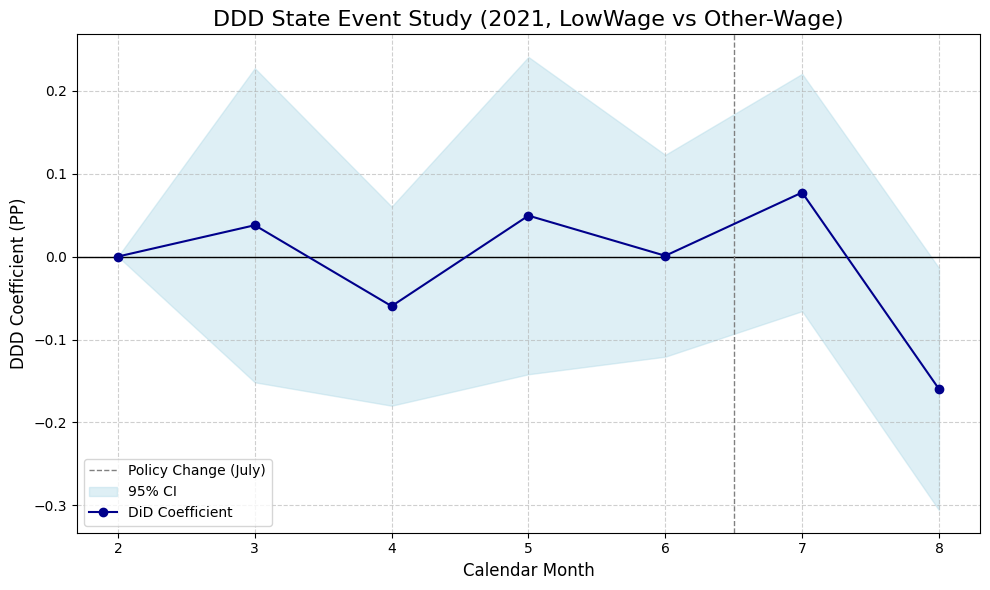


--- RUNNING MAIN ANALYSIS (LowWage) FOR YEAR: 2019 ---

--- Step 3: Preparing Final 2019 STATE Panel (LowWage) ---
Created 'LowWage' variable from 'IND'.
Base 2019 panel (Holzer States, Feb-Aug, valid industry) constructed with 7728 observations.
Other Wage (n=5550), Low Wage (n=2178)

--- Step 4: Merging Controls into 2019 panel (LowWage) ---
Final 2019 panel with controls constructed with 0 observations.
ERROR: Panel for 2019 is empty after merging controls.

--- RUNNING SENSITIVITY TEST (CollegeGrad) FOR YEAR: 2021 ---

--- Step 3: Preparing Final 2021 STATE Panel (CollegeGrad) ---
Created 'CollegeGrad' variable from 'EDUC'.
Base 2021 panel (Holzer States, Feb-Aug, valid education) constructed with 11278 observations.
Not College Grad (n=8350), College Grad (n=2928)

--- Step 4: Merging Controls into 2021 panel (CollegeGrad) ---
Final 2021 panel with controls constructed with 11278 observations.

>>> SENSITIVITY MODEL: DDD (2021, All Ages, Holzer States, CollegeGrad) <<<
Using form

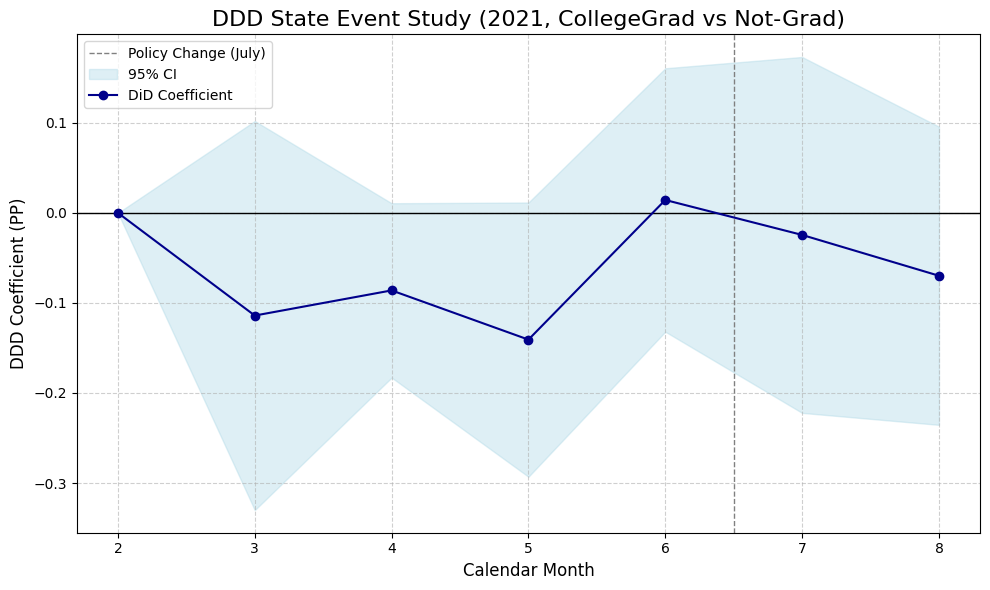

In [50]:
#%%
# =============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# =============================================================================
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

#%%
# =============================================================================
# CELL 2: HELPER FUNCTIONS (PLOTTING & PRINTING)
# =============================================================================

def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None, policy_month=7):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    'policy_month' is the first month of the post-period (e.g., 7 for July)
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    # --- FIX: Escape parentheses in C(TreatState) ---
    interaction_base = rf"C\(TreatState\)\[T\.1\]:C({variable})" # Escaped ( ) [ . ]
    if ddd_term:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}$"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < {policy_month}) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month with coef=0
    if ref_month not in est_df['relative_month'].values:
        ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
        plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    else:
        plot_df = est_df.copy()
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in policy_month)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < policy_month]['pval']
    if pre_trend_pvals.empty:
        print(f"No pre-trends (< {policy_month}) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)') # Keep as July for comparison
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month", fontsize=12) # Generic x-axis label
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()

#%%
# =============================================================================
# CELL 3: CORE ANALYSIS FUNCTIONS
# =============================================================================

def run_state_did_analysis(df, year, holzer_treat_fips, holzer_control_fips, monthly_covid, monthly_stringency, control_vars, policy_month=7):
    """
    Main analysis function for 2021 (main) and 2019 (placebo) using LOWWAGE (industry).
    """
    
    print("\n" + "="*80)
    print(f"--- RUNNING MAIN ANALYSIS (LowWage) FOR YEAR: {year} ---")
    print("="*80)

    # --- Step 3: Prepare Final STATE Panel ---
    print(f"\n--- Step 3: Preparing Final {year} STATE Panel (LowWage) ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in CPS data.")
        return
    
    df_year = df[df['YEAR'] == year].copy()
    if df_year.empty:
        print(f"ERROR: No data found for {year}.")
        return
    
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- *** MODIFIED: Define LowWage Group based on IND *** ---
    df_year['IND'] = pd.to_numeric(df_year['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): 
            return 1
        elif x > 0: 
            return 0
        else:
            return np.nan 

    df_year['LowWage'] = df_year['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    
    df_year = df_year[df_year['STATEFIP'].isin(included_states)].copy()
    df_year['TreatState'] = df_year['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_year['date'] = pd.to_datetime(df_year['YEAR'].astype(str) + '-' + df_year['MONTH'].astype(str) + '-01')
    
    df_year.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_year['status_next_month'] = df_year.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_year[df_year['EMPSTAT'].between(20, 22)].copy() 
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) 
    
    # Define Post period (July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= policy_month) & (unemployed_df['MONTH'] <= policy_month + 1)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] 
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) 
    
    print(f"Base {year} panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")

    # --- Step 4: Merge Controls ---
    print(f"\n--- Step 4: Merging Controls into {year} panel (LowWage) ---")
    
    # Filter controls for the specific year
    monthly_covid_year = monthly_covid[monthly_covid['YEAR'] == year]
    
    final_panel_with_controls = pd.merge(final_panel, monthly_covid_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    
    current_control_vars = ['log_monthly_cases'] # Start with cases
    
    if not monthly_stringency.empty:
        monthly_stringency_year = monthly_stringency[monthly_stringency['YEAR'] == year]
        if not monthly_stringency_year.empty:
            final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
            current_control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=current_control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final {year} panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print(f"ERROR: Panel for {year} is empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(f">>> FINAL MODEL: DDD ({year}, All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print(f"\nStarting {year} DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results ({year}, All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in current_control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
            
            print("\n--- Interpretation ---")
            if year == 2019:
                if pval_ddd < 0.10: print(f"PLACEBO TEST FAILED: Found a significant effect (p={pval_ddd:.3f}) in placebo year.")
                else: print(f"PLACEBO TEST PASSED: No significant effect found (p={pval_ddd:.3f}).")
            else:
                if pval_ddd < 0.10: print(f"Result: Found a statistically significant differential effect (p={pval_ddd:.3f}).")
                else: print(f"Result: No statistically significant differential effect found (p={pval_ddd:.3f}).")

        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during {year} DDD estimation: {e}")

    # --- Step 5b: Run Separate DiD Models by Wage Group ---
    print("\n" + "="*80)
    print(f">>> Step 5b: Separate 2x2 DiD Models by Wage Group ({year}, LowWage) <<<")
    print("="*80)
    
    other_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 0].copy()
    low_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 1].copy()
    print(f"Running DiD for Other Wage group (n={len(other_wage_panel)})")
    print(f"Running DiD for Low Wage group (n={len(low_wage_panel)})")

    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(2, "avg_stringency")
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=other_wage_panel, weights=other_wage_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': other_wage_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for OTHER WAGE Group (LowWage=0) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_other:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_other:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Other Wage DiD estimation: {e}")

    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for LOW WAGE Group (LowWage=1) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_low:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_low:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Low Wage DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(f">>> VALIDATION: Event Study on DDD Model (LowWage) ({year}) <<<")
    print("="*80)

    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print(f"\nStarting {year} DDD event study estimation...")
    try:
        es_data = final_panel_with_controls.copy()
        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            f"DDD_State_AllAges_HolzerStates_LowWage_{year}", 
            variable="MONTH", 
            ddd_term="LowWage",
            policy_month=policy_month
        )
        plot_did_event_study(plot_df_ddd, f"DDD State Event Study ({year}, LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during {year} event study estimation: {e}")
        import traceback
        traceback.print_exc()

def run_college_grad_sensitivity_test(df, year, holzer_treat_fips, holzer_control_fips, monthly_covid, monthly_stringency, control_vars, policy_month=7):
    """
    SENSITIVITY TEST function for 2021 using CollegeGrad (education).
    """
    
    print("\n" + "="*80)
    print(f"--- RUNNING SENSITIVITY TEST (CollegeGrad) FOR YEAR: {year} ---")
    print("="*80)

    # --- Step 3: Prepare Final STATE Panel ---
    print(f"\n--- Step 3: Preparing Final {year} STATE Panel (CollegeGrad) ---")
    
    # Check for EDUC
    if 'EDUC' not in df.columns:
        print("ERROR: 'EDUC' (Education) not found in CPS data. Skipping sensitivity test.")
        return
    
    df_year = df[df['YEAR'] == year].copy()
    if df_year.empty:
        print(f"ERROR: No data found for {year}.")
        return
    
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- *** DEFINE CollegeGrad Group based on EDUC *** ---
    # EDUC >= 111 (Bachelor's degree)
    df_year['EDUC'] = pd.to_numeric(df_year['EDUC'], errors='coerce')
    
    def define_college_grad(x):
        if x >= 111: # Bachelor's degree or higher
            return 1
        elif x > 0: # All other valid education codes
            return 0
        else:
            return np.nan 

    df_year['CollegeGrad'] = df_year['EDUC'].apply(define_college_grad)
    print(f"Created 'CollegeGrad' variable from 'EDUC'.")
    
    df_year = df_year[df_year['STATEFIP'].isin(included_states)].copy()
    df_year['TreatState'] = df_year['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_year['date'] = pd.to_datetime(df_year['YEAR'].astype(str) + '-' + df_year['MONTH'].astype(str) + '-01')
    
    df_year.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_year['status_next_month'] = df_year.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_year[df_year['EMPSTAT'].between(20, 22)].copy() 
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) 
    
    # Define Post period (July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= policy_month) & (unemployed_df['MONTH'] <= policy_month + 1)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'CollegeGrad']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] 
    final_panel['CollegeGrad'] = final_panel['CollegeGrad'].astype(int) 
    
    print(f"Base {year} panel (Holzer States, Feb-Aug, valid education) constructed with {len(final_panel)} observations.")
    print(f"Not College Grad (n={len(final_panel[final_panel['CollegeGrad']==0])}), College Grad (n={len(final_panel[final_panel['CollegeGrad']==1])})")

    # --- Step 4: Merge Controls ---
    print(f"\n--- Step 4: Merging Controls into {year} panel (CollegeGrad) ---")
    
    # Filter controls for the specific year
    monthly_covid_year = monthly_covid[monthly_covid['YEAR'] == year]
    
    final_panel_with_controls = pd.merge(final_panel, monthly_covid_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    
    current_control_vars = ['log_monthly_cases'] # Start with cases
    
    if not monthly_stringency.empty:
        monthly_stringency_year = monthly_stringency[monthly_stringency['YEAR'] == year]
        if not monthly_stringency_year.empty:
            final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
            current_control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    final_panel_with_controls.dropna(subset=current_control_vars, inplace=True) # Drop only if controls are missing
    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final {year} panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print(f"ERROR: Panel for {year} is empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (CollegeGrad) ---
    print("\n" + "="*80)
    print(f">>> SENSITIVITY MODEL: DDD ({year}, All Ages, Holzer States, CollegeGrad) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post * CollegeGrad", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts.insert(2, "avg_stringency")
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print(f"\nStarting {year} DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        ddd_term = 'TreatState:Post:CollegeGrad'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results ({year}, All Ages, Holzer States, CollegeGrad) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:CollegeGrad', 'Post:CollegeGrad'] + [v for v in current_control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
            
            print("\n--- Interpretation ---")
            if pval_ddd < 0.10: print(f"Result: Found a statistically significant differential effect (p={pval_ddd:.3f}).")
            else: print(f"Result: No statistically significant differential effect found (p={pval_ddd:.3f}).")
            print("This tests if the effect for College Grads was different from non-grads.")

        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during {year} DDD estimation: {e}")

    # --- Step 5b: Run Separate DiD Models by Wage Group ---
    print("\n" + "="*80)
    print(f">>> Step 5b: Separate 2x2 DiD Models by Group ({year}, CollegeGrad) <<<")
    print("="*80)
    
    non_grad_panel = final_panel_with_controls[final_panel_with_controls['CollegeGrad'] == 0].copy()
    grad_panel = final_panel_with_controls[final_panel_with_controls['CollegeGrad'] == 1].copy()
    print(f"Running DiD for Not College Grad group (n={len(non_grad_panel)})")
    print(f"Running DiD for College Grad group (n={len(grad_panel)})")

    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_parts_simple_did.insert(2, "avg_stringency")
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=non_grad_panel, weights=non_grad_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': non_grad_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for NOT COLLEGE GRAD Group (CollegeGrad=0) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_other:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_other:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Not College Grad DiD estimation: {e}")

    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=grad_panel, weights=grad_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': grad_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for COLLEGE GRAD Group (CollegeGrad=1) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_low:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_low:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} College Grad DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(f">>> VALIDATION: Event Study on DDD Model (CollegeGrad) ({year}) <<<")
    print("="*80)

    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * CollegeGrad", "C(STATEFIP)"]
    if 'log_monthly_cases' in final_panel_with_controls.columns:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in final_panel_with_controls.columns:
        formula_es_parts.insert(2, "avg_stringency")
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print(f"\nStarting {year} DDD event study estimation...")
    try:
        es_data = final_panel_with_controls.copy()
        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            f"DDD_State_AllAges_HolzerStates_CollegeGrad_{year}", 
            variable="MONTH", 
            ddd_term="CollegeGrad",
            policy_month=policy_month
        )
        plot_did_event_study(plot_df_ddd, f"DDD State Event Study ({year}, CollegeGrad vs Not-Grad)")

    except Exception as e:
        print(f"\nAn error occurred during {year} event study estimation: {e}")
        import traceback
        traceback.print_exc()

#%%
# =============================================================================
# CELL 4: MAIN EXECUTION SCRIPT
# =============================================================================

def run_state_did_simplified_controls(cps_file='cps_00005.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Main function to load data and run analysis for 2021 and placebo year (if available).
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        # Load CPS data (main file)
        df = pd.read_csv(cps_path) 
        # policy_df = pd.read_csv(policy_path, parse_dates=['date']) # Not needed for 2x2
        
        # Load controls (all years)
        covid_df = pd.read_csv(covid_path, na_values='.'); 
        ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        
        # --- *** NEW: Check available years *** ---
        available_years = sorted(df['YEAR'].unique())
        print(f"All data loaded successfully.")
        print(f"Available years found in {cps_file}: {available_years}")
        # --- *** END NEW *** ---

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls (All Years) ---
    print("\n--- Step 2: Preparing Controls (All Years) ---")
    
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    monthly_covid = covid_df.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] 
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        # Filter to relevant years
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'].isin(available_years))].copy()
        
        # --- *** SYNTAX ERROR FIX *** ---
        # Was: pd.to_numeric(ox_strigencyIndex'], errors='coerce')
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        # --- *** END FIX *** ---
        
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            # Check if we have data for our specific years of interest
            if 2021 in monthly_stringency['YEAR'].unique() or 2019 in monthly_stringency['YEAR'].unique():
                 control_vars.append('avg_stringency')
            else:
                print("Warning: OxCGRT data processed, but no matching 2019 or 2021 state data found. Skipping stringency.")
        else:
            print("Warning: OxCGRT data was processed, but no matching state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Run Main Analysis for 2021 (LowWage) ---
    if 2021 in available_years:
        run_state_did_analysis(
            df=df, 
            year=2021, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("ERROR: Year 2021 not found in CPS data. Cannot run main analysis.")
        print("="*80)
    
    # --- Run Placebo Test for 2019 (LowWage) ---
    if 2019 in available_years:
        run_state_did_analysis(
            df=df, 
            year=2019, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Placebo policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("WARNING: Year 2019 not found in CPS data. Skipping 2019 Placebo Test.")
        if 2020 in available_years:
            print("Note: 2020 data is available, but it is unsuitable for a placebo test due to the COVID-19 pandemic.")
        print("="*80)

    # --- *** NEW: Run Sensitivity Test for 2021 (CollegeGrad) *** ---
    if 2021 in available_years:
        run_college_grad_sensitivity_test(
            df=df, 
            year=2021, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("WARNING: Year 2021 not found. Skipping CollegeGrad sensitivity test.")
        print("="*80)

#%%
# =============================================================================
# CELL 5: SCRIPT ENTRY POINT
# =============================================================================

if __name__ == '__main__':
    run_state_did_simplified_controls(cps_file='cps_00005.csv')



--- Step 1: Loading Data ---
All data loaded successfully.
Available years found in cps_00005.csv: [np.int64(2019), np.int64(2020), np.int64(2021)]

--- Step 2: Preparing Controls (All Years) ---
Controls prepared.

--- RUNNING MAIN ANALYSIS (LowWage) FOR YEAR: 2021 ---

--- Step 3: Preparing Final 2021 STATE Panel (LowWage) ---
Created 'LowWage' variable from 'IND'.
Base 2021 panel (Holzer States, Feb-Aug, valid industry) constructed with 10577 observations.
Other Wage (n=7526), Low Wage (n=3051)

--- Step 4: Merging Controls into 2021 panel (LowWage) ---
Final 2021 panel with controls constructed with 10577 observations.

>>> FINAL MODEL: DDD (2021, All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting 2021 DDD model estimation...

--- DDD Results (2021, All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): -0.0564
P-value: 0.1108

--- Coefficient Summary (Key Vari

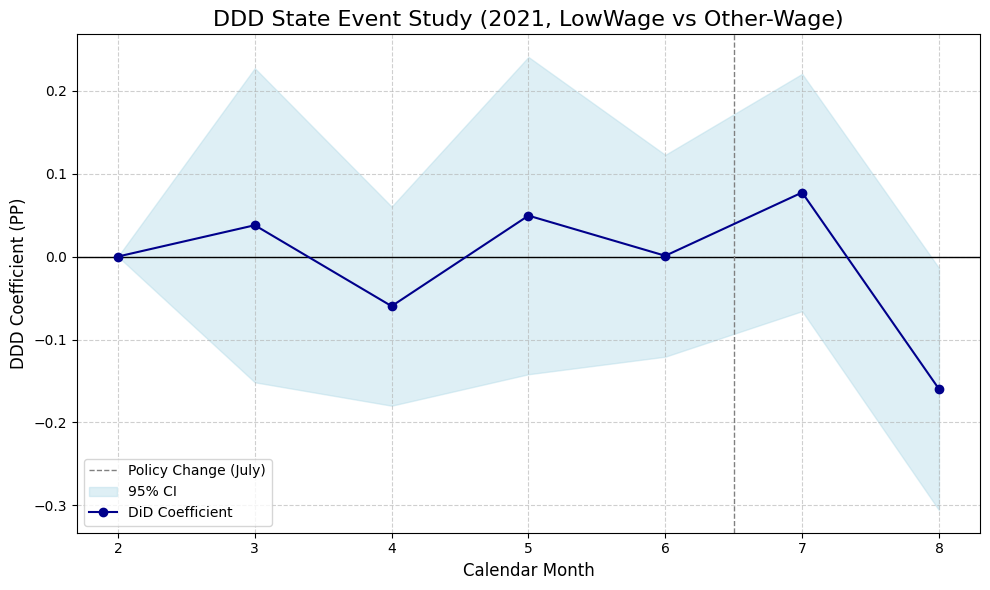


--- RUNNING MAIN ANALYSIS (LowWage) FOR YEAR: 2019 ---

--- Step 3: Preparing Final 2019 STATE Panel (LowWage) ---
Created 'LowWage' variable from 'IND'.
Base 2019 panel (Holzer States, Feb-Aug, valid industry) constructed with 7728 observations.
Other Wage (n=5550), Low Wage (n=2178)

--- Step 4: Merging Controls into 2019 panel (LowWage) ---
Final 2019 panel with controls constructed with 7728 observations.

>>> FINAL MODEL: DDD (2019, All Ages, Holzer States, LowWage) <<<
Using formula:
found_job ~ TreatState * Post * LowWage + C(STATEFIP) + C(MONTH)

Starting 2019 DDD model estimation...

--- DDD Results (2019, All Ages, Holzer States, LowWage) ---
Key Coefficient (TreatState:Post:LowWage): 0.0679
P-value: 0.2569

--- Coefficient Summary (Key Variables) ---
TreatState:Post:LowWage  : Coef =   0.0679, P-val = 0.2569
TreatState:Post          : Coef =  -0.0167, P-val = 0.5960
TreatState:LowWage       : Coef =   0.0246, P-val = 0.2728
Post:LowWage             : Coef =  -0.0538, P-val 

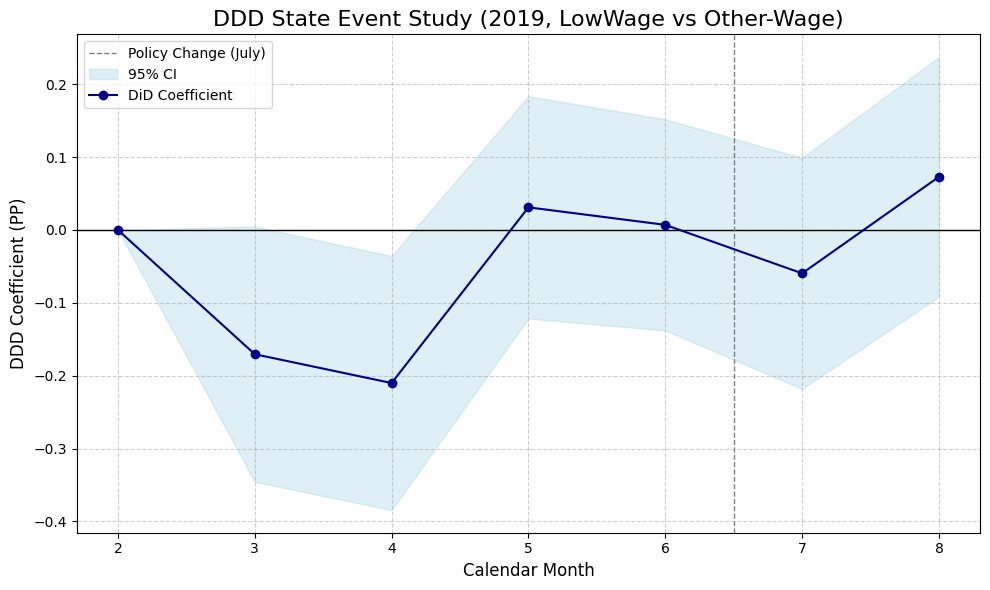


--- RUNNING SENSITIVITY TEST (CollegeGrad) FOR YEAR: 2021 ---

--- Step 3: Preparing Final 2021 STATE Panel (CollegeGrad) ---
Created 'CollegeGrad' variable from 'EDUC'.
Base 2021 panel (Holzer States, Feb-Aug, valid education) constructed with 11278 observations.
Not College Grad (n=8350), College Grad (n=2928)

--- Step 4: Merging Controls into 2021 panel (CollegeGrad) ---
Final 2021 panel with controls constructed with 11278 observations.

>>> SENSITIVITY MODEL: DDD (2021, All Ages, Holzer States, CollegeGrad) <<<
Using formula:
found_job ~ TreatState * Post * CollegeGrad + log_monthly_cases + C(STATEFIP) + C(MONTH)

Starting 2021 DDD model estimation...

--- DDD Results (2021, All Ages, Holzer States, CollegeGrad) ---
Key Coefficient (TreatState:Post:CollegeGrad): 0.0212
P-value: 0.7429

--- Coefficient Summary (Key Variables) ---
TreatState:Post:CollegeGrad: Coef =   0.0212, P-val = 0.7429
TreatState:Post          : Coef =   0.0209, P-val = 0.3133
TreatState:CollegeGrad   : Coef 

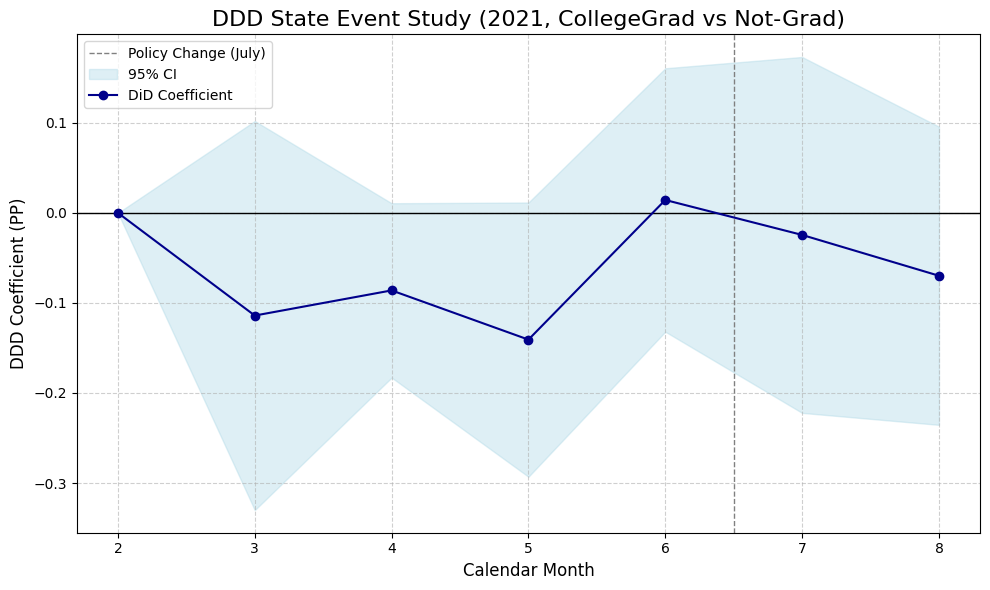

In [51]:
#%%
# =============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# =============================================================================
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt # Import for plotting
import statsmodels.tools.sm_exceptions # Import for warning handling

# Suppress common warnings
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings(action='ignore', category=statsmodels.tools.sm_exceptions.ValueWarning)

#%%
# =============================================================================
# CELL 2: HELPER FUNCTIONS (PLOTTING & PRINTING)
# =============================================================================

def print_did_event_study_coeffs(results, title, variable="MONTH", ddd_term=None, policy_month=7):
    """
    Finds, prints, and returns a DataFrame of event study coefficients
    from a statsmodels results object.
    'variable' argument is used to build the regex pattern.
    'ddd_term' specifies the third interaction term (e.g., 'LowWage')
    'policy_month' is the first month of the post-period (e.g., 7 for July)
    """
    print("\n" + "="*60 + f"\n>>> Event Study Numerical Results: {title} <<<\n" + "="*60)
    
    # --- *** MODIFIED FOR DDD *** ---
    # --- FIX: Escape parentheses in C(TreatState) ---
    interaction_base = rf"C\(TreatState\)\[T\.1\]:C({variable})" # Escaped ( ) [ . ]
    if ddd_term:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]:{ddd_term}$"
        print(f"Coefficients for: {interaction_base} * {ddd_term} interactions")
    else:
        # --- FIX: Escape parentheses in C(TreatState) ---
        interaction_full = rf"C\(TreatState\)\[T\.1\]:C\({variable}.*?\[T\.(\d+)\]$"
        print(f"Coefficients for: {interaction_base} interactions")
        
    print(f"Checking PTA: Pre-trend p-values (Months < {policy_month}) should be > 0.10")
    print("-" * 60)
    
    did_terms = []
    term_pattern = rf'{interaction_full}'
    
    # Find the reference level from the formula if possible
    ref_month = 2 # Defaulting to 2 (February) as per our formula
    try:
        ref_match = re.search(r'C\(MONTH, Treatment\(reference=(\d+)\)\)', results.model.formula)
        if ref_match:
            ref_month = int(ref_match.group(1))
    except:
        pass # Keep default

    for var in results.params.index:
        match = re.search(term_pattern, var, re.IGNORECASE) # Add re.IGNORECASE for flexibility
        if match:
            month = int(match.group(1))
            did_terms.append({
                'relative_month': month, # Keeping col name 'relative_month' for plotting
                'coef': results.params[var],
                'pval': results.pvalues[var],
                'stderr': results.bse[var]
            })
            
    if not did_terms:
        print("No event study coefficients found.")
        print(f"Pattern searched for: {term_pattern}")
        print("This often means the control group was dropped or there is perfect collinearity.")
        print("Check if the variable names in the regex match the model output *exactly*.")
        print("-" * 60)
        return None
        
    est_df = pd.DataFrame(did_terms).sort_values('relative_month')
    
    # Add the reference month with coef=0
    if ref_month not in est_df['relative_month'].values:
        ref_month_df = pd.DataFrame([{'relative_month': ref_month, 'coef': 0, 'stderr': 0, 'pval': 1.0}])
        plot_df = pd.concat([est_df, ref_month_df]).sort_values('relative_month').reset_index(drop=True)
    else:
        plot_df = est_df.copy()
    
    # Print the table
    for _, row in plot_df.iterrows():
        print(f"Month {int(row.relative_month):>2}:  Coef = {row.coef:>7.4f},  SE = {row.stderr:>6.4f},  P = {row.pval:.4f}")
    print("-" * 60)
    
    # Check PTA (Policy starts in policy_month)
    pre_trend_pvals = plot_df[plot_df['relative_month'] < policy_month]['pval']
    if pre_trend_pvals.empty:
        print(f"No pre-trends (< {policy_month}) to test.")
    # Check if all p-values (excl. ref month) are > 0.10
    elif (pre_trend_pvals[plot_df['relative_month'] != ref_month] > 0.10).all():
        print("SUCCESS: Parallel Trends Assumption appears satisfied.")
    else:
        print("WARNING: Parallel Trends Assumption may be VIOLATED.")
        
    return plot_df

def plot_did_event_study(plot_df, title):
    """
    Plots the event study coefficients and 95% confidence intervals.
    """
    if plot_df is None or plot_df.empty:
        print(f"Skipping plot {title}: No data.");
        return
        
    plt.figure(figsize=(10, 6))
    # Reference lines
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(6.5, color='gray', linestyle='--', linewidth=1, label='Policy Change (July)') # Keep as July for comparison
    
    # Calculate 95% CI
    plot_df['ci_low'] = plot_df['coef'] - 1.96 * plot_df['stderr']
    plot_df['ci_high'] = plot_df['coef'] + 1.96 * plot_df['stderr']
    
    # Plot CI band and coefficients
    plt.fill_between(plot_df['relative_month'], plot_df['ci_low'], plot_df['ci_high'], color='lightblue', alpha=0.4, label='95% CI')
    plt.plot(plot_df['relative_month'], plot_df['coef'], marker='o', linestyle='-', color='darkblue', label='DiD Coefficient')
    
    plt.title(title, fontsize=16)
    plt.xlabel("Calendar Month", fontsize=12) # Generic x-axis label
    plt.ylabel("DDD Coefficient (PP)", fontsize=12)
    plt.xticks(plot_df['relative_month'].unique()) # Shows 2, 3, 4, 5, 6, 7, 8
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the figure
    safe_title = title.replace(' ','_').replace('(','').replace(')','').replace(',','').lower()
    plt.savefig(f"{safe_title}.png")
    plt.show()

#%%
# =============================================================================
# CELL 3: CORE ANALYSIS FUNCTIONS
# =============================================================================

def run_state_did_analysis(df, year, holzer_treat_fips, holzer_control_fips, monthly_covid, monthly_stringency, control_vars, policy_month=7):
    """
    Main analysis function for 2021 (main) and 2019 (placebo) using LOWWAGE (industry).
    """
    
    print("\n" + "="*80)
    print(f"--- RUNNING MAIN ANALYSIS (LowWage) FOR YEAR: {year} ---")
    print("="*80)

    # --- Step 3: Prepare Final STATE Panel ---
    print(f"\n--- Step 3: Preparing Final {year} STATE Panel (LowWage) ---")
    
    # Check for IND
    if 'IND' not in df.columns:
        print("ERROR: 'IND' (Industry) not found in CPS data.")
        return
    
    df_year = df[df['YEAR'] == year].copy()
    if df_year.empty:
        print(f"ERROR: No data found for {year}.")
        return
    
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- *** MODIFIED: Define LowWage Group based on IND *** ---
    df_year['IND'] = pd.to_numeric(df_year['IND'], errors='coerce')
    
    def define_low_wage(x):
        if (4670 <= x < 5790) or (8560 <= x < 8700): 
            return 1
        elif x > 0: 
            return 0
        else:
            return np.nan 

    df_year['LowWage'] = df_year['IND'].apply(define_low_wage)
    print(f"Created 'LowWage' variable from 'IND'.")
    
    df_year = df_year[df_year['STATEFIP'].isin(included_states)].copy()
    df_year['TreatState'] = df_year['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_year['date'] = pd.to_datetime(df_year['YEAR'].astype(str) + '-' + df_year['MONTH'].astype(str) + '-01')
    
    df_year.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_year['status_next_month'] = df_year.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_year[df_year['EMPSTAT'].between(20, 22)].copy() 
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) 
    
    # Define Post period (July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= policy_month) & (unemployed_df['MONTH'] <= policy_month + 1)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    essential_cols = ['found_job', 'LNKFW1MWT', 'STATEFIP', 'MONTH', 'YEAR', 'TreatState', 'Post', 'date', 'LowWage']
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'LowWage']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] 
    final_panel['LowWage'] = final_panel['LowWage'].astype(int) 
    
    print(f"Base {year} panel (Holzer States, Feb-Aug, valid industry) constructed with {len(final_panel)} observations.")
    print(f"Other Wage (n={len(final_panel[final_panel['LowWage']==0])}), Low Wage (n={len(final_panel[final_panel['LowWage']==1])})")

    # --- Step 4: Merge Controls ---
    print(f"\n--- Step 4: Merging Controls into {year} panel (LowWage) ---")
    
    # Filter controls for the specific year
    monthly_covid_year = monthly_covid[monthly_covid['YEAR'] == year]
    
    final_panel_with_controls = pd.merge(final_panel, monthly_covid_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    
    current_control_vars = [] # Start with none
    
    # --- *** 2019 PLACEBO FIX *** ---
    # Only add COVID cases as a control variable for 2020+
    if year > 2019:
        current_control_vars.append('log_monthly_cases')
    # --- *** END FIX *** ---

    if not monthly_stringency.empty:
        monthly_stringency_year = monthly_stringency[monthly_stringency['YEAR'] == year]
        if not monthly_stringency_year.empty:
            final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
            current_control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    
    # --- *** 2019 PLACEBO FIX *** ---
    # Drop only if controls (if any) are missing. For 2019, this list will be empty
    # unless stringency data for 2019 is found.
    if current_control_vars: # Only drop if there are controls to check
        final_panel_with_controls.dropna(subset=current_control_vars, inplace=True)
    # --- *** END FIX *** ---

    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final {year} panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print(f"ERROR: Panel for {year} is empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (LowWage) ---
    print("\n" + "="*80)
    print(f">>> FINAL MODEL: DDD ({year}, All Ages, Holzer States, LowWage) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post * LowWage", "C(STATEFIP)", "C(MONTH)"]
    
    # --- *** 2019 PLACEBO FIX *** ---
    # Conditionally add controls to formula
    if 'log_monthly_cases' in current_control_vars:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in current_control_vars:
        formula_parts.insert(1, "avg_stringency") # Insert at 1, so cases is 2
    # --- *** END FIX *** ---
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print(f"\nStarting {year} DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        ddd_term = 'TreatState:Post:LowWage'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results ({year}, All Ages, Holzer States, LowWage) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:LowWage', 'Post:LowWage'] + [v for v in current_control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
            
            print("\n--- Interpretation ---")
            if year == 2019:
                if pval_ddd < 0.10: print(f"PLACEBO TEST FAILED: Found a significant effect (p={pval_ddd:.3f}) in placebo year.")
                else: print(f"PLACEBO TEST PASSED: No significant effect found (p={pval_ddd:.3f}).")
            else:
                if pval_ddd < 0.10: print(f"Result: Found a statistically significant differential effect (p={pval_ddd:.3f}).")
                else: print(f"Result: No statistically significant differential effect found (p={pval_ddd:.3f}).")

        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during {year} DDD estimation: {e}")

    # --- Step 5b: Run Separate DiD Models by Wage Group ---
    print("\n" + "="*80)
    print(f">>> Step 5b: Separate 2x2 DiD Models by Wage Group ({year}, LowWage) <<<")
    print("="*80)
    
    other_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 0].copy()
    low_wage_panel = final_panel_with_controls[final_panel_with_controls['LowWage'] == 1].copy()
    print(f"Running DiD for Other Wage group (n={len(other_wage_panel)})")
    print(f"Running DiD for Low Wage group (n={len(low_wage_panel)})")

    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    # --- *** 2019 PLACEBO FIX *** ---
    if 'log_monthly_cases' in current_control_vars:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in current_control_vars:
        formula_parts_simple_did.insert(1, "avg_stringency")
    # --- *** END FIX *** ---
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=other_wage_panel, weights=other_wage_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': other_wage_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for OTHER WAGE Group (LowWage=0) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_other:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_other:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Other Wage DiD estimation: {e}")

    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=low_wage_panel, weights=low_wage_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': low_wage_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for LOW WAGE Group (LowWage=1) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_low:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_low:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Low Wage DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(f">>> VALIDATION: Event Study on DDD Model (LowWage) ({year}) <<<")
    print("="*80)

    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * LowWage", "C(STATEFIP)"]
    # --- *** 2019 PLACEBO FIX *** ---
    if 'log_monthly_cases' in current_control_vars:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in current_control_vars:
        formula_es_parts.insert(1, "avg_stringency")
    # --- *** END FIX *** ---
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print(f"\nStarting {year} DDD event study estimation...")
    try:
        es_data = final_panel_with_controls.copy()
        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            f"DDD_State_AllAges_HolzerStates_LowWage_{year}", 
            variable="MONTH", 
            ddd_term="LowWage",
            policy_month=policy_month
        )
        plot_did_event_study(plot_df_ddd, f"DDD State Event Study ({year}, LowWage vs Other-Wage)")

    except Exception as e:
        print(f"\nAn error occurred during {year} event study estimation: {e}")
        import traceback
        traceback.print_exc()

def run_college_grad_sensitivity_test(df, year, holzer_treat_fips, holzer_control_fips, monthly_covid, monthly_stringency, control_vars, policy_month=7):
    """
    SENSITIVITY TEST function for 2021 using CollegeGrad (education).
    """
    
    print("\n" + "="*80)
    print(f"--- RUNNING SENSITIVITY TEST (CollegeGrad) FOR YEAR: {year} ---")
    print("="*80)

    # --- Step 3: Prepare Final STATE Panel ---
    print(f"\n--- Step 3: Preparing Final {year} STATE Panel (CollegeGrad) ---")
    
    # Check for EDUC
    if 'EDUC' not in df.columns:
        print("ERROR: 'EDUC' (Education) not found in CPS data. Skipping sensitivity test.")
        return
    
    df_year = df[df['YEAR'] == year].copy()
    if df_year.empty:
        print(f"ERROR: No data found for {year}.")
        return
    
    included_states = holzer_treat_fips.union(holzer_control_fips)
    
    # --- *** DEFINE CollegeGrad Group based on EDUC *** ---
    # EDUC >= 111 (Bachelor's degree)
    df_year['EDUC'] = pd.to_numeric(df_year['EDUC'], errors='coerce')
    
    def define_college_grad(x):
        if x >= 111: # Bachelor's degree or higher
            return 1
        elif x > 0: # All other valid education codes
            return 0
        else:
            return np.nan 

    df_year['CollegeGrad'] = df_year['EDUC'].apply(define_college_grad)
    print(f"Created 'CollegeGrad' variable from 'EDUC'.")
    
    df_year = df_year[df_year['STATEFIP'].isin(included_states)].copy()
    df_year['TreatState'] = df_year['STATEFIP'].apply(lambda x: 1 if x in holzer_treat_fips else 0)
    df_year['date'] = pd.to_datetime(df_year['YEAR'].astype(str) + '-' + df_year['MONTH'].astype(str) + '-01')
    
    df_year.sort_values(['CPSIDP', 'YEAR', 'MONTH'], inplace=True)
    df_year['status_next_month'] = df_year.groupby('CPSIDP')['EMPSTAT'].shift(-1)
    unemployed_df = df_year[df_year['EMPSTAT'].between(20, 22)].copy() 
    unemployed_df['found_job'] = unemployed_df['status_next_month'].between(10, 12).astype(int) 
    
    # Define Post period (July/August)
    unemployed_df['Post'] = ((unemployed_df['MONTH'] >= policy_month) & (unemployed_df['MONTH'] <= policy_month + 1)).astype(int)

    # Filter to Holzer's timeframe (Feb-Aug)
    final_panel = unemployed_df[unemployed_df['MONTH'].between(2, 8)].copy()
    
    # Keep only essential columns + weights + IDs for clustering
    final_panel = final_panel.dropna(subset=['found_job', 'LNKFW1MWT', 'CollegeGrad']) 
    final_panel = final_panel[final_panel['LNKFW1MWT'] > 0] 
    final_panel['CollegeGrad'] = final_panel['CollegeGrad'].astype(int) 
    
    print(f"Base {year} panel (Holzer States, Feb-Aug, valid education) constructed with {len(final_panel)} observations.")
    print(f"Not College Grad (n={len(final_panel[final_panel['CollegeGrad']==0])}), College Grad (n={len(final_panel[final_panel['CollegeGrad']==1])})")

    # --- Step 4: Merge Controls ---
    print(f"\n--- Step 4: Merging Controls into {year} panel (CollegeGrad) ---")
    
    # Filter controls for the specific year
    monthly_covid_year = monthly_covid[monthly_covid['YEAR'] == year]
    
    final_panel_with_controls = pd.merge(final_panel, monthly_covid_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
    
    current_control_vars = [] # Start with none
    
    # --- *** 2019 PLACEBO FIX *** ---
    if year > 2019:
        current_control_vars.append('log_monthly_cases')
    # --- *** END FIX *** ---
    
    if not monthly_stringency.empty:
        monthly_stringency_year = monthly_stringency[monthly_stringency['YEAR'] == year]
        if not monthly_stringency_year.empty:
            final_panel_with_controls = pd.merge(final_panel_with_controls, monthly_stringency_year, on=['STATEFIP', 'YEAR', 'MONTH'], how='left')
            current_control_vars.append('avg_stringency')
        
    original_count = len(final_panel_with_controls)
    
    # --- *** 2019 PLACEBO FIX *** ---
    if current_control_vars:
        final_panel_with_controls.dropna(subset=current_control_vars, inplace=True)
    # --- *** END FIX *** ---

    dropped_count = original_count - len(final_panel_with_controls)
    if dropped_count > 0:
        print(f"Warning: Dropped {dropped_count} observations missing control data.")
        
    print(f"Final {year} panel with controls constructed with {len(final_panel_with_controls)} observations.")
    if len(final_panel_with_controls) == 0:
        print(f"ERROR: Panel for {year} is empty after merging controls."); return

    # --- Step 5: Run State-Level DDD Model (CollegeGrad) ---
    print("\n" + "="*80)
    print(f">>> SENSITIVITY MODEL: DDD ({year}, All Ages, Holzer States, CollegeGrad) <<<")
    print("="*80)
    
    formula_parts = ["found_job ~ TreatState * Post * CollegeGrad", "C(STATEFIP)", "C(MONTH)"]
    # --- *** 2019 PLACEBO FIX *** ---
    if 'log_monthly_cases' in current_control_vars:
        formula_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in current_control_vars:
        formula_parts.insert(1, "avg_stringency")
    # --- *** END FIX *** ---
        
    final_formula = " + ".join(formula_parts)
    print(f"Using formula:\n{final_formula}")
    
    print(f"\nStarting {year} DDD model estimation...")
    try:
        model_ddd = smf.wls(formula=final_formula, data=final_panel_with_controls, weights=final_panel_with_controls['LNKFW1MWT'])
        results_ddd = model_ddd.fit(cov_type='cluster', cov_kwds={'groups': final_panel_with_controls['STATEFIP']})
        
        ddd_term = 'TreatState:Post:CollegeGrad'
        if ddd_term in results_ddd.params:
            coef_ddd = results_ddd.params[ddd_term]
            pval_ddd = results_ddd.pvalues[ddd_term]
            
            print(f"\n--- DDD Results ({year}, All Ages, Holzer States, CollegeGrad) ---")
            print(f"Key Coefficient ({ddd_term}): {coef_ddd:.4f}")
            print(f"P-value: {pval_ddd:.4f}\n")
            
            print("--- Coefficient Summary (Key Variables) ---")
            key_vars_to_print = [ddd_term, 'TreatState:Post', 'TreatState:CollegeGrad', 'Post:CollegeGrad'] + [v for v in current_control_vars if v in results_ddd.params.index]
            for var in key_vars_to_print:
                if var in results_ddd.params:
                    print(f"{var:<25}: Coef = {results_ddd.params[var]:>8.4f}, P-val = {results_ddd.pvalues[var]:.4f}")
            
            print("\n--- Interpretation ---")
            if pval_ddd < 0.10: print(f"Result: Found a statistically significant differential effect (p={pval_ddd:.3f}).")
            else: print(f"Result: No statistically significant differential effect found (p={pval_ddd:.3f}).")
            print("This tests if the effect for College Grads was different from non-grads.")

        else: print(f"ERROR: '{ddd_term}' coefficient was not estimated.")

    except Exception as e:
        print(f"\nAn error occurred during {year} DDD estimation: {e}")

    # --- Step 5b: Run Separate DiD Models by Wage Group ---
    print("\n" + "="*80)
    print(f">>> Step 5b: Separate 2x2 DiD Models by Group ({year}, CollegeGrad) <<<")
    print("="*80)
    
    non_grad_panel = final_panel_with_controls[final_panel_with_controls['CollegeGrad'] == 0].copy()
    grad_panel = final_panel_with_controls[final_panel_with_controls['CollegeGrad'] == 1].copy()
    print(f"Running DiD for Not College Grad group (n={len(non_grad_panel)})")
    print(f"Running DiD for College Grad group (n={len(grad_panel)})")

    formula_parts_simple_did = ["found_job ~ TreatState * Post", "C(STATEFIP)", "C(MONTH)"]
    # --- *** 2019 PLACEBO FIX *** ---
    if 'log_monthly_cases' in current_control_vars:
        formula_parts_simple_did.insert(1, "log_monthly_cases")
    if 'avg_stringency' in current_control_vars:
        formula_parts_simple_did.insert(1, "avg_stringency")
    # --- *** END FIX *** ---
    simple_did_formula = " + ".join(formula_parts_simple_did)
    
    print(f"\nUsing simple DiD formula: {simple_did_formula}")

    try:
        model_did_other = smf.wls(formula=simple_did_formula, data=non_grad_panel, weights=non_grad_panel['LNKFW1MWT'])
        results_did_other = model_did_other.fit(cov_type='cluster', cov_kwds={'groups': non_grad_panel['STATEFIP']})
        
        coef_did_other = results_did_other.params.get('TreatState:Post', np.nan)
        pval_did_other = results_did_other.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for NOT COLLEGE GRAD Group (CollegeGrad=0) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_other:.4f}")
        print(f"P-value: {pval_did_other:.4f}")
        if pval_did_other < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_other:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_other:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} Not College Grad DiD estimation: {e}")

    try:
        model_did_low = smf.wls(formula=simple_did_formula, data=grad_panel, weights=grad_panel['LNKFW1MWT'])
        results_did_low = model_did_low.fit(cov_type='cluster', cov_kwds={'groups': grad_panel['STATEFIP']})
        
        coef_did_low = results_did_low.params.get('TreatState:Post', np.nan)
        pval_did_low = results_did_low.pvalues.get('TreatState:Post', np.nan)
        
        print(f"\n--- DiD Results for COLLEGE GRAD Group (CollegeGrad=1) [{year}] ---")
        print(f"Key Coefficient (TreatState:Post): {coef_did_low:.4f}")
        print(f"P-value: {pval_did_low:.4f}")
        if pval_did_low < 0.10: print(f"Result: Statistically SIGNIFICANT effect (p={pval_did_low:.3f}).")
        else: print(f"Result: NOT statistically significant (p={pval_did_low:.3f}).")
        
    except Exception as e:
        print(f"\nAn error occurred during {year} College Grad DiD estimation: {e}")
    
    # --- Step 6: Run Event Study for Validation (DDD) ---
    print("\n" + "="*80)
    print(f">>> VALIDATION: Event Study on DDD Model (CollegeGrad) ({year}) <<<")
    print("="*80)

    formula_es_parts = ["found_job ~ C(TreatState) * C(MONTH, Treatment(reference=2)) * CollegeGrad", "C(STATEFIP)"]
    # --- *** 2019 PLACEBO FIX *** ---
    if 'log_monthly_cases' in current_control_vars:
        formula_es_parts.insert(1, "log_monthly_cases")
    if 'avg_stringency' in current_control_vars:
        formula_es_parts.insert(1, "avg_stringency")
    # --- *** END FIX *** ---
        
    final_formula_es = " + ".join(formula_es_parts)
    print(f"\nUsing event study formula:\n{final_formula_es}")
    
    print(f"\nStarting {year} DDD event study estimation...")
    try:
        es_data = final_panel_with_controls.copy()
        print(f"Running event study on {len(es_data)} observations.")
        
        model_es = smf.wls(formula=final_formula_es, data=es_data, weights=es_data['LNKFW1MWT'])
        results_es = model_es.fit(cov_type='cluster', cov_kwds={'groups': es_data['STATEFIP']})
        
        plot_df_ddd = print_did_event_study_coeffs(
            results_es, 
            f"DDD_State_AllAges_HolzerStates_CollegeGrad_{year}", 
            variable="MONTH", 
            ddd_term="CollegeGrad",
            policy_month=policy_month
        )
        plot_did_event_study(plot_df_ddd, f"DDD State Event Study ({year}, CollegeGrad vs Not-Grad)")

    except Exception as e:
        print(f"\nAn error occurred during {year} event study estimation: {e}")
        import traceback
        traceback.print_exc()

#%%
# =============================================================================
# CELL 4: MAIN EXECUTION SCRIPT
# =============================================================================

def run_state_did_simplified_controls(cps_file='cps_00005.csv',
                                      policy_file='Policy Milestones - State.csv',
                                      covid_file='COVID - State - Daily.csv',
                                      oxcgrt_file='OxCGRT_US_latest.csv'):
    """
    Main function to load data and run analysis for 2021 and placebo year (if available).
    """
    # --- Step 0: Define Holzer States ---
    holzer_treat_fips = {1, 5, 13, 16, 19, 28, 29, 30, 31, 33, 38, 40, 45, 46, 48, 49, 54, 56}
    holzer_control_fips = {6, 8, 9, 10, 11, 15, 17, 20, 21, 23, 25, 26, 27, 32, 34, 35, 36, 37, 41, 42, 44, 50, 51, 53, 55}
    
    # --- Step 1: Load All Data ---
    print("--- Step 1: Loading Data ---")
    try:
        home_dir = os.path.expanduser('~'); downloads_dir = os.path.join(home_dir, 'downloads')
        cps_path = os.path.join(downloads_dir, cps_file); policy_path = os.path.join(downloads_dir, policy_file)
        covid_path = os.path.join(downloads_dir, covid_file); oxcgrt_path = os.path.join(downloads_dir, oxcgrt_file)
        
        # Load CPS data (main file)
        df = pd.read_csv(cps_path) 
        # policy_df = pd.read_csv(policy_path, parse_dates=['date']) # Not needed for 2x2
        
        # Load controls (all years)
        covid_df = pd.read_csv(covid_path, na_values='.'); 
        ox_df = pd.read_csv(oxcgrt_path, low_memory=False)
        
        # --- *** NEW: Check available years *** ---
        available_years = sorted(df['YEAR'].unique())
        print(f"All data loaded successfully.")
        print(f"Available years found in {cps_file}: {available_years}")
        # --- *** END NEW *** ---

    except FileNotFoundError as e:
        print(f"ERROR: Could not find a file. {e}");
        return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- Step 2: Prepare Controls (All Years) ---
    print("\n--- Step 2: Preparing Controls (All Years) ---")
    
    # COVID Cases
    if 'new_case_count' not in covid_df.columns:
        print("ERROR: 'new_case_count' missing from COVID file."); return
    covid_df['new_cases_numeric'] = pd.to_numeric(covid_df['new_case_count'], errors='coerce').fillna(0)
    monthly_covid = covid_df.groupby(['statefips', 'year', 'month'])['new_cases_numeric'].sum().reset_index()
    monthly_covid.rename(columns={'statefips': 'STATEFIP', 'year': 'YEAR', 'month': 'MONTH', 'new_cases_numeric': 'monthly_cases'}, inplace=True)
    monthly_covid['log_monthly_cases'] = np.log(monthly_covid['monthly_cases'] + 1)
    
    # Stringency
    monthly_stringency = pd.DataFrame()
    control_vars = ['log_monthly_cases'] 
    try:
        ox_df['date'] = pd.to_datetime(ox_df['Date'], format='%Y%m%d')
        ox_df['YEAR'] = ox_df['date'].dt.year; ox_df['MONTH'] = ox_df['date'].dt.month
        # Filter to relevant years
        ox_us_states = ox_df[(ox_df['CountryCode'] == 'USA') & (ox_df['Jurisdiction'] == 'STATE_TOTAL') & (ox_df['YEAR'].isin(available_years))].copy()
        
        # --- *** SYNTAX ERROR FIX *** ---
        ox_us_states['StringencyIndex_numeric'] = pd.to_numeric(ox_us_states['StringencyIndex'], errors='coerce')
        # --- *** END FIX *** ---
        
        fips_map = {'US_AL': 1, 'US_AK': 2, 'US_AZ': 4, 'US_AR': 5, 'US_CA': 6, 'US_CO': 8, 'US_CT': 9, 'US_DE': 10, 'US_DC': 11, 'US_FL': 12, 'US_GA': 13, 'US_HI': 15, 'US_ID': 16, 'US_IL': 17, 'US_IN': 18, 'US_IA': 19, 'US_KS': 20, 'US_KY': 21, 'US_LA': 22, 'US_ME': 23, 'US_MD': 24, 'US_MA': 25, 'US_MI': 26, 'US_MN': 27, 'US_MS': 28, 'US_MO': 29, 'US_MT': 30, 'US_NE': 31, 'US_NV': 32, 'US_NH': 33, 'US_NJ': 34, 'US_NM': 35, 'US_NY': 36, 'US_NC': 37, 'US_ND': 38, 'US_OH': 39, 'US_OK': 40, 'US_OR': 41, 'US_PA': 42, 'US_RI': 44, 'US_SC': 45, 'US_SD': 46, 'US_TN': 47, 'US_TX': 48, 'US_UT': 49, 'US_VT': 50, 'US_VA': 51, 'US_WA': 53, 'US_WV': 54, 'US_WI': 55, 'US_WY': 56}
        ox_us_states['STATEFIP'] = ox_us_states['RegionCode'].map(fips_map)
        monthly_stringency = ox_us_states.groupby(['STATEFIP', 'YEAR', 'MONTH'])['StringencyIndex_numeric'].mean().reset_index()
        monthly_stringency.rename(columns={'StringencyIndex_numeric': 'avg_stringency'}, inplace=True)
        
        if not monthly_stringency.empty:
            # Check if we have data for our specific years of interest
            if 2021 in monthly_stringency['YEAR'].unique() or 2019 in monthly_stringency['YEAR'].unique():
                 control_vars.append('avg_stringency')
            else:
                print("Warning: OxCGRT data processed, but no matching 2019 or 2021 state data found. Skipping stringency.")
        else:
            print("Warning: OxCGRT data was processed, but no matching state data was found. Skipping stringency.")
            
    except Exception as e:
        print(f"Warning: Could not process OxCGRT data: {e}. Skipping stringency.")
    print("Controls prepared.")

    # --- Run Main Analysis for 2021 (LowWage) ---
    if 2021 in available_years:
        run_state_did_analysis(
            df=df, 
            year=2021, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("ERROR: Year 2021 not found in CPS data. Cannot run main analysis.")
        print("="*80)
    
    # --- Run Placebo Test for 2019 (LowWage) ---
    if 2019 in available_years:
        run_state_did_analysis(
            df=df, 
            year=2019, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Placebo policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("WARNING: Year 2019 not found in CPS data. Skipping 2019 Placebo Test.")
        if 2020 in available_years:
            print("Note: 2020 data is available, but it is unsuitable for a placebo test due to the COVID-19 pandemic.")
        print("="*80)

    # --- *** NEW: Run Sensitivity Test for 2021 (CollegeGrad) *** ---
    if 2021 in available_years:
        run_college_grad_sensitivity_test(
            df=df, 
            year=2021, 
            holzer_treat_fips=holzer_treat_fips, 
            holzer_control_fips=holzer_control_fips, 
            monthly_covid=monthly_covid, 
            monthly_stringency=monthly_stringency,
            control_vars=control_vars,
            policy_month=7 # Policy starts in July
        )
    else:
        print("\n" + "="*80)
        print("WARNING: Year 2021 not found. Skipping CollegeGrad sensitivity test.")
        print("="*80)

#%%
# =============================================================================
# CELL 5: SCRIPT ENTRY POINT
# =============================================================================

if __name__ == '__main__':
    run_state_did_simplified_controls(cps_file='cps_00005.csv')

